## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [1]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "mdape": run.data.metrics.get("mdape"),
                "r2": run.data.metrics.get("r2"),
                "feature_transformes" : run.data.tags.get("feature_transform_map"),
                "parametros": run.data.params,
                "features": run.data.tags.get('feature_history_columns'),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("mdape", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [2]:
def _log_feature_history(X, run_name=None):
    """Registra histórico de features no MLflow para o run atual."""
    try:
        cols = list(X.columns) if hasattr(X, "columns") else []
        mlflow.set_tag("feature_history_run_name", run_name or "")
        mlflow.set_tag("feature_history_num_columns", len(cols))
        if cols:
            mlflow.set_tag("feature_history_columns", ",".join(cols[:50]))
            if len(cols) > 50:
                mlflow.set_tag("feature_history_columns_truncated", "true")

            feature_history_path = Path(tempfile.mkdtemp()) / "feature_history.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_history_path, index=False)
            mlflow.log_artifact(str(feature_history_path), artifact_path="feature_history")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature history: {exc}")


def _log_feature_store(
    X,
    run_name,
    feature_group_name,
    description,
    source,
    ):
    """Registra metadados de feature store no MLflow para o run atual."""
    try:
        mlflow.set_tag("feature_store_run_name", run_name or "")
        mlflow.set_tag("feature_store_group_name", feature_group_name)
        mlflow.set_tag("feature_store_description", description)
        mlflow.set_tag("feature_store_source", source)
        mlflow.set_tag("feature_store_num_columns", X.shape[1] if hasattr(X, "shape") else None)

        cols = list(X.columns) if hasattr(X, "columns") else []
        if cols:
            feature_store_path = Path(tempfile.mkdtemp()) / "feature_store.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_store_path, index=False)
            mlflow.log_artifact(str(feature_store_path), artifact_path="feature_store")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature store: {exc}")


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn, fit_kwargs=None):
    """Treina um pipeline com logging automático de métricas e parâmetros no MLflow."""
    mlflow.start_run(run_name=nome)
    is_keras_model = hasattr(estimador, "save") and not hasattr(estimador, "get_params")
    mlflow.set_tag("modelo_tipo", "keras" if is_keras_model else "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    if callable(criar_preprocessador_fn):
        preprocessor = criar_preprocessador_fn()
    else:
        preprocessor = criar_preprocessador_fn

    if preprocessor is None:
        raise ValueError("`criar_preprocessador_fn` deve retornar um preprocessor ou receber um objeto transformador.")

    try:
        if is_keras_model:
            X_tr_pre = preprocessor.fit_transform(X_tr)
            X_te_pre = preprocessor.transform(X_te)
            fit_kwargs = fit_kwargs or {}
            estimador.fit(X_tr_pre, y_tr, validation_data=(X_te_pre, y_te), verbose=0, **fit_kwargs)
            pred = estimador.predict(X_te_pre).ravel()
            mlflow.keras.log_model(estimador, artifact_path=nome)

            preprocessor_path = Path(tempfile.mkdtemp()) / "preprocessor.joblib"
            joblib.dump(preprocessor, preprocessor_path)
            mlflow.log_artifact(str(preprocessor_path), artifact_path=nome)
            trained_model = estimador
        else:
            pipe = Pipeline([
                ("preprocessador", preprocessor),
                ("modelo", estimador),
            ])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            mlflow.sklearn.log_model(pipe, name=nome)
            trained_model = pipe

            if hasattr(estimador, "get_params"):
                params = estimador.get_params()
                for k, v in list(params.items())[:20]:
                    v_str = str(v)[:100] if v is not None else "None"
                    mlflow.log_param(f"modelo__{k}", v_str)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return trained_model, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()
        


def _build_keras_from_trial(trial, input_dim):
    """Reconstrói um modelo Keras a partir dos parâmetros de um trial Optuna."""
    def _trial_param(name):
        params = getattr(trial, "_params", None) or getattr(trial, "params", None) or {}
        return params.get(name, None)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    num_camadas = _trial_param("num_camadas")
    if num_camadas is None:
        num_camadas = trial.suggest_int("num_camadas", 1, 4)

    for i in range(num_camadas):
        unidades = _trial_param(f"unidades_{i}")
        if unidades is None:
            unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)

        dropout = _trial_param(f"dropout_{i}")
        if dropout is None:
            dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)

        model.add(layers.Dense(int(unidades), activation="relu"))
        if dropout and float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1))
    lr = _trial_param("learning_rate")
    if lr is None:
        lr = trial.suggest_categorical("learning_rate", [1e-2, 1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [3]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [4]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")
 
from  mlflow_manager import MLflowManager

# Ou explicito:
mlf = MLflowManager(
    nome_experimento="joinville_imoveis",
    databricks_workspace_path="/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville",
)



Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 


In [5]:
mlf.conectar()

mlf.listar_experimentos()
df_compa = mlf.comparar_modelos("imoveis-joinville-valor")

2026/06/19 11:21:32 INFO mlflow.tracking.fluent: Experiment with name '/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville' does not exist. Creating a new experiment.


[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville
Total de experimentos: 6

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-joinville (ID: 3096404772377850)
   Runs: 0

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-itapoa-valor (ID: 3192446127778310)
   Runs: 10
   ... optuna_GradientBoosting|power_median_ohe|sqrt_7feats - RMSE: N/A
   OK best_GradientBoosting|raw_zero_ord|none_6feats - RMSE: 375950.9720
   OK optuna_GradientBoosting|raw_zero_ord|none_6feats - RMSE: N/A
   OK best_GradientBoosting|raw_zero_ord|yeojohnson_5feats - RMSE: 386099.4076
   OK optuna_GradientBoosting|raw_zero_ord|yeojohnson_5feats - RMSE: N/A
   ... e mais 5 runs

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-curitiba-valor (ID: 4237570276861303)
   Runs: 10
   OK MLP|power_median_ohe|sqrt_tem_elevador_2026_06 - RMSE: 1084443.6711
   OK MLP|raw_zero_ord|log_tem_elevador_2026_06 - RMSE

## Carregar dados

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [ ]:
cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / "sao_paulo" / "vila-mariana"
pd_joinville = pd.read_parquet(PASTA_DADOS / f'sao_paulo_vila-mariana_imoveis_limpo_2026-06.parquet')

In [7]:
len(pd_joinville['lat'].unique())

272

In [ ]:
pd_joinville['lat'].value_counts()

In [23]:
from criando_indices_individuais import CriandoIndicesIndividuais

cidade = "Joinville, Santa Catarina, Brasil"

indices = CriandoIndicesIndividuais(cidade=cidade)

pd_joinville = indices.calcular_indices(imoveis_df=pd_joinville)

Baixando dados de POIs do OpenStreetMap...
  -> hospital...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> mercado...
  -> farmacia...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> parque...


...

  -> escola...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> policia...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


7 categorias de POIs carregadas.


In [24]:
pd_joinville

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,dist_policia_mais_proximo,qtd_policia_500m,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,score_educacao
0,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 45m² - João...",45.0,1,1,2,120882.0,NaN,"Rua Manuel Agostinho de Carvalho, N. 350 APTO....",NaN,...,1471.477239,0,0.239235,0.128039,2.685370e-01,0.208653,0.014956,2.217697e+00,3.749417e-01,0.213628
1,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 47m² - Comasa",47.0,1,1,2,300000.0,185.0,"Rua Avencal - Comasa, Joinville - SC",310.0,...,1066.892315,0,0.205452,0.467852,7.663622e-01,0.832756,0.002670,2.781389e+00,4.910244e-01,0.111882
2,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 46m² - Glória",46.0,1,1,2,363999.0,0.0,"Rua Nazareno - Glória, Joinville - SC",0.0,...,1898.371681,0,0.125874,0.148110,1.728856e-01,1.217481,0.005222,4.919988e+00,2.820753e-01,0.096252
3,https://www.zapimoveis.com.br/imovel/venda-con...,"Conjunto Comercial / Sala à venda, 47m² - Bom ...",47.0,0,0,0,440000.0,650.0,"Avenida Rolf Wiest - Bom Retiro, Joinville - SC",1500.0,...,1042.009731,0,3.045542,0.104905,6.967124e-02,0.937175,0.488548,1.772390e+00,4.992376e-01,3.024561
4,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 45m² - Para...",45.0,1,1,2,123904.0,NaN,"Paranaguamirim, Joinville - SC",NaN,...,3722.823099,0,1.456385,0.154298,3.466743e-02,0.058264,0.146523,2.317327e+00,8.358576e-02,1.425526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26900,https://sc.olx.com.br/norte-de-santa-catarina/...,"Apartamento com 1 quarto à venda, 54m² por R$ ...",54.0,1,1,1,527000.0,NaN,"Centro, Joinville, SC, 89201450",NaN,...,537668.829340,0,0.000000,0.000000,7.436325e-196,0.000000,0.000000,1.887283e-193,2.132699e-156,0.000000
26901,https://sc.olx.com.br/norte-de-santa-catarina/...,APARTAMENTO no GUANABARA com 1 quartos para VE...,31.0,1,1,1,139000.0,NaN,"Guanabara, Joinville, SC, 89207650",NaN,...,1444.515637,0,1.793914,0.468804,1.286366e-01,0.958050,0.019331,5.911438e+00,3.817419e-01,1.700153
26902,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento | Joinville | América,49.0,1,2,1,1303591.0,NaN,"América, Joinville, SC, 89201602",NaN,...,263.781175,1,1.159247,0.027948,1.002660e+00,0.161728,0.060918,5.895541e+00,1.138740e+00,1.153657
26903,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento 2 Quartos Piscina Floresta Joinville,43.0,1,1,2,229000.0,NaN,"Floresta, Joinville, SC, 89212170",NaN,...,775.672394,0,0.229776,0.787239,4.218518e-02,0.263439,0.085453,2.636973e+01,5.962383e-01,0.072328


## Pré-processamento e features

In [25]:
#TARGET = "valor_imovel"
TARGET = "preco_por_m2"

NUMERIC_FEATURES = [
    #"metragem", 
    "banheiros", 
    "vagas", 
    "quartos",
    #"condominio", "iptu", 
    #"lat", "lng", "p25_bairro", "p50_bairro", "p75_bairro", 
    #"score",
    "score_escola_privada",
    "score_escola_publica",
    "score_hospitais",
    "score_mercado",
    "score_farmacia",
    "score_parque",
    "score_seguranca",
    "score_educacao"
]
CATEGORICAL_FEATURES = ["tipo_imovel", 
                        "bairro", 
                        #"fonte"
                        ]

# Colunas derivadas do preço — não entram no modelo (data leakage)
COLUNAS_LEAKAGE = [
    #"preco_por_m2", 
    "valor_imovel",
    "metragem",
    "desvio_mediana", 
    "faixa"]

df_modelo = pd_joinville.copy()
df_modelo = df_modelo.dropna(subset=[TARGET, "metragem"])
df_modelo = df_modelo[
    (df_modelo["metragem"] > 10)
    #& (df_modelo[TARGET] >= 50_000)
    #& (df_modelo[TARGET] <= 25_000_000)
    & ((df_modelo["tipo_imovel"] == "casa") | (df_modelo["preco_por_m2"] >= 100))
    & ((df_modelo["tipo_imovel"] == "apartamento") | (df_modelo["preco_por_m2"] >= 100))
].copy()

X = df_modelo[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_modelo[TARGET]

X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.4, random_state=42
)

print(f"Amostras para treino: {len(X_train):,} | teste: {len(X_test):,} | validação: {len(X_val):,}")

Amostras para treino: 19,923 | teste: 2,657 | validação: 3,985


In [26]:
def _replace_inf(X):
    return np.nan_to_num(
        np.asarray(X, dtype=np.float64),
        nan=np.nan,
        posinf=np.nan,
        neginf=np.nan,
    )


def criar_preprocessador(imputer=None, scaler=None, encoder=None):
    if imputer is None:
        imputer = SimpleImputer(strategy="median")
    if scaler is None:
        scaler = StandardScaler()
    if encoder is None:
        encoder = OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False)
        
    numeric_pipe = Pipeline([
        (
            "replace_inf",
            FunctionTransformer(
                _replace_inf,
                validate=False,
                feature_names_out="one-to-one",
            ),
        ),
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def metricas(nome, y_true, y_pred):

    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}


def treinar_pipeline(nome, estimador, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ("preprocessador", 
         ),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return pipe, metricas(nome, y_te, pred)





## Otimização de hiperparâmetros (Optuna)

Busca os melhores hiperparâmetros com **validação cruzada (3 folds)** no conjunto de treino, minimizando RMSE. Ajuste `N_TRIALS` para mais/menos precisão (mais trials = mais lento).

In [27]:
N_TRIALS = 40
N_FOLDS = 3
RANDOM_STATE = 42

from sklearn.model_selection import cross_validate  # <-- Certifique-se de importar este cara

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
melhores_hiperparametros_modelos = {}
estudos_optuna = {}


def otimizar_modelo(nome, factory):
    """factory(trial) -> estimador sklearn/catboost/lightgbm"""

    def objective(trial):
        modelo = factory(trial)
        pipe = Pipeline([
            ("preprocessador", criar_preprocessador()),
            ("modelo", modelo),
        ])
        
        scoring_metrics = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    }
        
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring_metrics,
            n_jobs=-1,
        )
        
        #rmse_cv = -scores.mean()
        rmse_cv = -scores["test_rmse"].mean()
        mae_cv  = -scores["test_mae"].mean()
        mape_cv = -scores["test_mape"].mean()
        r2_cv   = scores["test_r2"].mean()

        with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
            mlflow.set_tag("modelo", nome)
            mlflow.set_tag("trial", trial.number)
            for param_name, param_value in trial.params.items():
                mlflow.log_param(param_name, str(param_value)[:100])
            mlflow.log_metric("rmse", rmse_cv)
            mlflow.log_metric("mae", mae_cv)
            mlflow.log_metric("mape", mape_cv)
            mlflow.log_metric("r2", r2_cv)
            _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")
            _log_feature_history(X_train, run_name=f"optuna_{nome}")


        return rmse_cv

    with mlflow.start_run(run_name=f"optuna_{nome}"):
        mlflow.set_tag("otimizacao", "optuna")
        mlflow.set_tag("modelo", nome)
        mlflow.log_param("n_trials", N_TRIALS)
        mlflow.log_param("n_folds", N_FOLDS)
        _log_feature_history(X_train, run_name=f"optuna_{nome}")
        _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")

        study = optuna.create_study(
            direction="minimize",
            study_name=nome,
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

        melhores_hiperparametros_modelos[nome] = study.best_params
        estudos_optuna[nome] = study

        for param_name, param_value in study.best_params.items():
            mlflow.log_param(f"best_{param_name}", str(param_value)[:100])
        mlflow.log_metric("best_rmse", study.best_value)

    print(f"{nome}: melhor RMSE CV = {study.best_value:,.2f} | params = {study.best_params}")
    return study


def factory_catboost(trial):
    return CatBoostRegressor(
        iterations=trial.suggest_int("iterations", 200, 800, step=50),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )


def factory_lightgbm(trial):
    return LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def factory_random_forest(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 0.9]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def factory_hist_gb(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
    )

In [28]:
# 1. Ajustamos a sua função para aceitar o objeto 'hp' (Hyperparameters)
def construir_modelo_otimizavel(hp, input_dim):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    
    # Otimiza o número de camadas ocultas (entre 1 e 4 camadas)
    for i in range(hp.Int("num_camadas", min_value=1, max_value=4, default=3)):
        # Otimiza o número de neurônios de cada camada (entre 64 e 512, pulando de 64 em 64)
        modelo.add(
            layers.Dense(
                units=hp.Int(f"unidades_{i}", min_value=64, max_value=512, step=64),
                activation="relu"
            )
        )
        # Otimiza a taxa de Dropout (de 0.0 a 0.4, variando de 0.1 em 0.1)
        modelo.add(layers.Dropout(rate=hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.4, step=0.1)))
    
    # Camada de saída (Regressão para o preço do imóvel)
    modelo.add(layers.Dense(1))
    
    # Otimiza a taxa de aprendizado do Adam (escolha entre 1e-2, 1e-3 ou 1e-4)
    lr = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return modelo

In [29]:
print("=== Otimização Optuna (pode levar alguns minutos) ===\n")

train_keras = False  # Defina como False se quiser pular a otimização do modelo Keras (MLP)

if train_keras:
    for nome, factory in [
        ("catboost", factory_catboost),
        ("lightgbm", factory_lightgbm),
        ("random_forest", factory_random_forest),
        ("hist_gradient_boosting", factory_hist_gb),
    ]:
        otimizar_modelo(nome, factory)

    pd.DataFrame(melhores_hiperparametros_modelos).T

=== Otimização Optuna (pode levar alguns minutos) ===



In [30]:
# Mude para o número real de colunas do seu X_train

train_mlp = False  # Defina como True para rodar a otimização do MLP (pode ser demorado)

preprocessador_keras = Pipeline([
    ("preprocessador", criar_preprocessador()),
    ("fix_inf", FunctionTransformer(
        lambda X: np.nan_to_num(np.asarray(X, dtype=np.float64), nan=np.nan, posinf=np.nan, neginf=np.nan),
        validate=False,
    )),
    ("clip_extreme", FunctionTransformer(
        lambda X: np.clip(X, -1e200, 1e200),
        validate=False,
    )),
    ("scaler", StandardScaler()),
])

X_train_keras = preprocessador_keras.fit_transform(X_train)
X_test_keras = preprocessador_keras.transform(X_test)
X_val_keras = preprocessador_keras.transform(X_val)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_val_log = np.log1p(y_val)

INPUT_DIM = X_train_keras.shape[1]

if train_mlp:             
    study, best_mlp = otimizar_mlp_com_mlflow(
        n_trials=30, 
        X_train_keras=X_train_keras, 
        y_train_keras=y_train_log, 
            x_val_keras=X_val_keras,
            y_val_keras=y_val_log,
        input_dim=X_train_keras.shape[1]
    )

## Treino e avaliação (hiperparâmetros otimizados)

Modelos treinados com os melhores hiperparâmetros encontrados pelo Optuna (seção anterior):
- **Regressão linear** (baseline, sem tuning)
- **Random Forest**, **HistGradientBoosting**, **LightGBM**, **CatBoost**
- **Rede neural** (Keras MLP)

In [21]:
result = comparar_modelos_mlflow("imoveis-joinville-valor")

Usando experimento encontrado: /Users/sehnemjeferson@gmail.com/imoveis-joinville-valor (ID: 3220922994350712)
Comparação de modelos treinados:
                                                             run_name         rmse          mae      mape     mdape        r2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         fea

In [22]:
result.sort_values("rmse")

,run_name,rmse,mae,mape,mdape,r2,feature_transformes,parametros,features,modelo,status
216,RandomForest|std_median_ohe|log_bairro_2026_06,976870.541346,299927.984911,24.442160,12.883245,0.675059,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir...","{'modelo': 'RandomForest', 'n_features': '23',...","metragem,quartos,banheiros,vagas,score_escola_...",None,FINISHED
157,RandomForest|robust_median_ohe|log_bairro_2026_06,976889.274384,299939.879703,24.442334,12.883245,0.675046,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir...","{'modelo': 'RandomForest', 'n_features': '23',...","metragem,quartos,banheiros,vagas,score_escola_...",None,FINISHED
282,RandomForest|robust_median_ohe|log_tipo_imovel...,977345.649057,300743.504884,24.470720,12.961824,0.674743,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir...","{'modelo': 'RandomForest', 'n_features': '22',...","metragem,quartos,banheiros,vagas,score_escola_...",None,FINISHED
383,RandomForest|std_median_ohe|log_tipo_imovel_20...,977388.820583,300727.926875,24.470248,12.961824,0.674714,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir...","{'modelo': 'RandomForest', 'n_features': '22',...","metragem,quartos,banheiros,vagas,score_escola_...",None,FINISHED
81,RandomForest|raw_zero_ord|yeojohnson_novo_lanc...,978439.530316,303025.014646,24.454839,13.247143,0.674014,"{""metragem"": ""yeojohnson"", ""quartos"": ""yeojohn...","{'modelo': 'RandomForest', 'n_features': '24',...","metragem,quartos,banheiros,vagas,score_escola_...",None,FINISHED
...,...,...,...,...,...,...,...,...,...,...,...
256,MLP_opt|quantile_median_ord|log_bairro_2026_06,NaN,NaN,NaN,NaN,NaN,None,"{'best_batch_size': '256', 'best_dropout_0': '...",None,keras,FINISHED
260,MLP_opt|minmax_mean_ohe|none_bairro_2026_06,NaN,NaN,NaN,NaN,NaN,None,"{'best_batch_size': '256', 'best_dropout_0': '...",None,keras,FINISHED
385,MLP_opt|robust_median_ohe|yeojohnson_tipo_imov...,NaN,NaN,NaN,NaN,NaN,None,"{'best_batch_size': '256', 'best_dropout_0': '...",None,keras,FINISHED
386,MLP_opt|raw_zero_ord|sqrt_tipo_imovel_2026_06,NaN,NaN,NaN,NaN,NaN,None,"{'best_batch_size': '256', 'best_dropout_0': '...",None,keras,FINISHED


In [91]:
from IPython.display import display

def pegando_melhores_modelos(result, modelos_esperados=None):
    # Modelos de interesse
    if modelos_esperados is not None:
        best_modelos = modelos_esperados
    else:
        best_modelos = ["keras", "random_forest", "lightgbm", "hist_gradient_boosting", "catboost"]

    # Filtra runs relevantes
    best_runs = result[result["modelo"].isin(best_modelos)].copy()
    if best_runs.empty:
        print("Nenhum run encontrado para os modelos esperados.")
    else:
        # Seleciona o run com menor RMSE por modelo
        best_idx = best_runs.groupby("modelo")["rmse"].idxmin()
        best_runs = best_runs.loc[best_idx].reset_index(drop=True)

        best_params_df = best_runs[["modelo", "run_name", "rmse", "mae", "mape", "r2", "parametros", "feature_sampled"]].copy()
        print("Melhores parâmetros por modelo:")
        display(best_params_df)

        import ast

        def _parse_params_field(p):
            # Caso os parâmetros venham como string literal
            if isinstance(p, str):
                try:
                    return ast.literal_eval(p)
                except Exception:
                    return p
            return p

        def _normalize_values(d):
            if not isinstance(d, dict):
                return d
            out = {}
            for k, v in d.items():
                if isinstance(v, str):
                    # bool
                    lv = v.lower()
                    if lv in ("true", "false"):
                        out[k] = lv == "true"
                        continue
                    # int
                    if v.isdigit():
                        out[k] = int(v)
                        continue
                    # float
                    try:
                        out[k] = float(v)
                        continue
                    except Exception:
                        out[k] = v
                else:
                    out[k] = v
            return out

        def build_model_from_params(modelo_nome, params):
            params = _parse_params_field(params)
            if isinstance(params, dict):
                params = _normalize_values(params)

            if modelo_nome == "keras":
                try:
                    trial = optuna.trial.FixedTrial(params)
                    return _build_keras_from_trial(trial, input_dim=X_train_keras.shape[1])
                except Exception as e:
                    raise RuntimeError(f"Falha ao reconstruir Keras: {e}")

            if modelo_nome == "random_forest":
                return RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)

            if modelo_nome == "lightgbm":
                return LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)

            if modelo_nome == "hist_gradient_boosting":
                return HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE)

            if modelo_nome == "catboost":
                return CatBoostRegressor(**params, random_state=RANDOM_STATE, verbose=0)

            raise ValueError(f"Modelo não suportado: {modelo_nome}")

        # Reconstrói modelos
        best_models = {}
        for _, row in best_runs.iterrows():
            nome = row["modelo"]
            params = row["parametros"]
            try:
                best_models[nome] = build_model_from_params(nome, params)
                print(f"Reconstruído: {nome}")
            except Exception as e:
                print(f"Erro reconstruindo {nome}: {e}")
        return best_models, [best_params_df['feature_sampled'].iloc[0]]


In [ ]:
best_models, features = pegando_melhores_modelos(result)

In [27]:
metricas_dict = {}
modelos_treinados = {}
for nome, modelo in best_models.items():
    print(f"\n--- Avaliando modelo: {nome} ---")
    if nome == "keras":
        # Para Keras, usamos os dados já pré-processados e log-transformados
        nome_modelo = f"{nome}_final"
        modelo_treinado, metricas_resultado = treinar_pipeline_com_mlflow(
            nome_modelo,
            modelo,
             X_train, y_train, X_test, y_test, criar_preprocessador)
    else:
        nome_modelo = f"{nome}_final"
        modelo_treinado, metricas_resultado = treinar_pipeline_com_mlflow(nome_modelo, modelo, X_train, y_train, X_test, y_test, criar_preprocessador)

    modelos_treinados[nome] = modelo_treinado
    metricas_dict[nome] = metricas_resultado
metricas_df = pd.DataFrame(metricas_dict).T


--- Avaliando modelo: catboost ---


2026/06/01 10:37:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 10:38:24 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


catboost_final: RMSE=R$ 2,830 | MAE=R$ 1,434 | MAPE=43.9% | R²=0.340
🏃 View run catboost_final at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/d79d4eb2019a44999244996b828cd63c
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604

--- Avaliando modelo: hist_gradient_boosting ---


2026/06/01 10:38:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 10:39:03 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


hist_gradient_boosting_final: RMSE=R$ 2,346 | MAE=R$ 1,495 | MAPE=47.3% | R²=0.546
🏃 View run hist_gradient_boosting_final at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/74187727558c4ede8e0bdd22096b715a
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604

--- Avaliando modelo: keras ---
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


...

keras_final: RMSE=R$ 2,650 | MAE=R$ 1,719 | MAPE=45.5% | R²=0.421
🏃 View run keras_final at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/7d3c3d06928e48ddaf0b9caf3606fe37
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604

--- Avaliando modelo: lightgbm ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001606 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2172
[LightGBM] [Info] Number of data points in the train set: 19923, number of used features: 49
[LightGBM] [Info] Start training from score 6573.598409


2026/06/01 10:40:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 10:40:29 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


lightgbm_final: RMSE=R$ 2,242 | MAE=R$ 1,427 | MAPE=43.8% | R²=0.585
🏃 View run lightgbm_final at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/45f04e00496f4489a4a8c70852f8a2fd
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604

--- Avaliando modelo: random_forest ---


2026/06/01 10:40:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 10:41:06 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


random_forest_final: RMSE=R$ 2,219 | MAE=R$ 1,387 | MAPE=43.5% | R²=0.594
🏃 View run random_forest_final at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/f30e59c4ffc64953a94135ee9e3c618d
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604


In [29]:
metricas_df

,rmse,mae,mape,r2
catboost,2830.297645,1434.073696,43.911488,0.339576
hist_gradient_boosting,2345.588655,1495.331528,47.302742,0.546411
keras,2650.017595,1718.577697,45.493064,0.421030
lightgbm,2242.491822,1426.562261,43.773001,0.585409
random_forest,2219.190593,1387.105572,43.529155,0.593980


In [30]:
melhor_modelo = metricas_df["rmse"].idxmin()
melhor_modelo

'random_forest'

## Importância das features (SHAP)

Análise de interpretabilidade com [SHAP](https://shap.readthedocs.io/): impacto de cada variável na predição de `valor_imovel`.

Usa o melhor modelo em árvore/boosting disponível (ou o modelo vencedor, se for sklearn).

Modelo selecionado para SHAP: random_forest
Features: 49 (11 num + 38 cat)
Features: 49, amostras SHAP: 500


tipo_imovel_apartamento      507.995642
score_hospitais              349.693332
score_escola_publica         347.122099
tipo_imovel_casa             329.566394
quartos                      301.184286
tipo_imovel_terreno          290.306778
vagas                        203.876360
banheiros                    180.989762
bairro_america               162.863288
score_parque                 104.007121
score_farmacia                97.867289
score_seguranca               95.981047
score_educacao                95.501216
score_escola_privada          88.727499
bairro_gloria                 84.860216
score_mercado                 72.015560
bairro_anita garibaldi        50.889118
bairro_infrequent_sklearn     43.508119
bairro_atiradores             31.349457
bairro_santo antonio          26.416378
dtype: float64

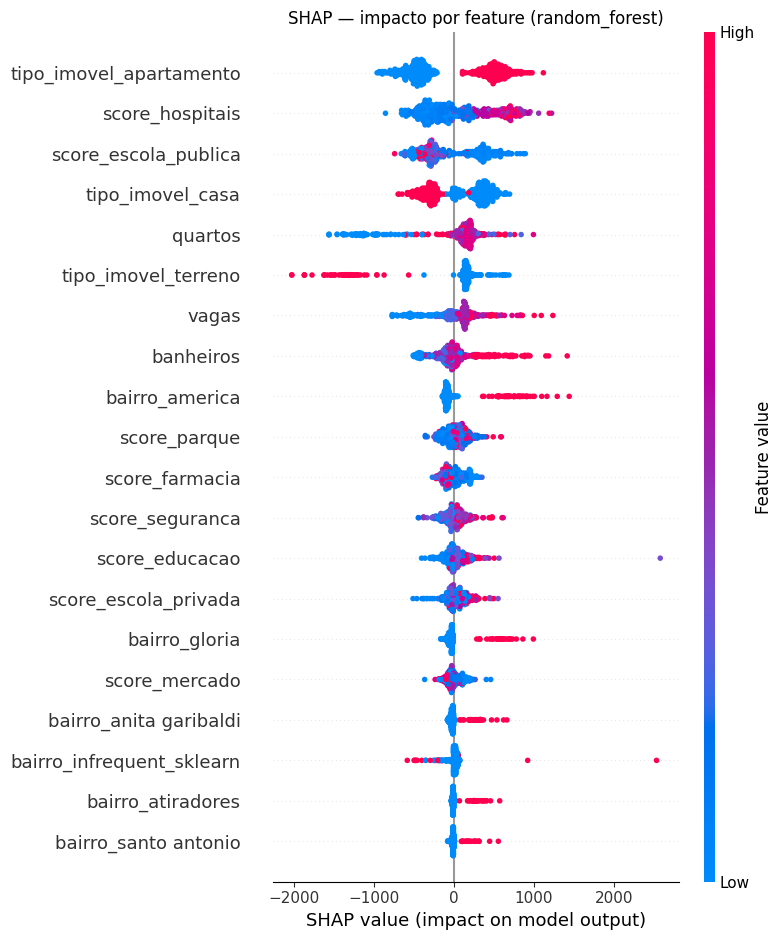

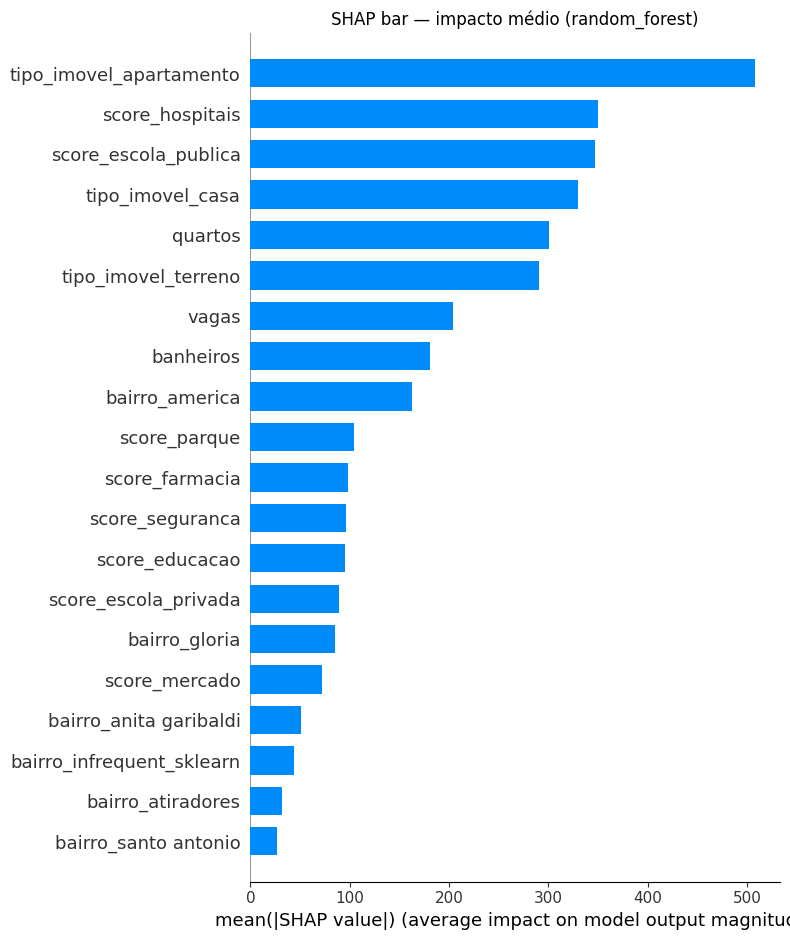

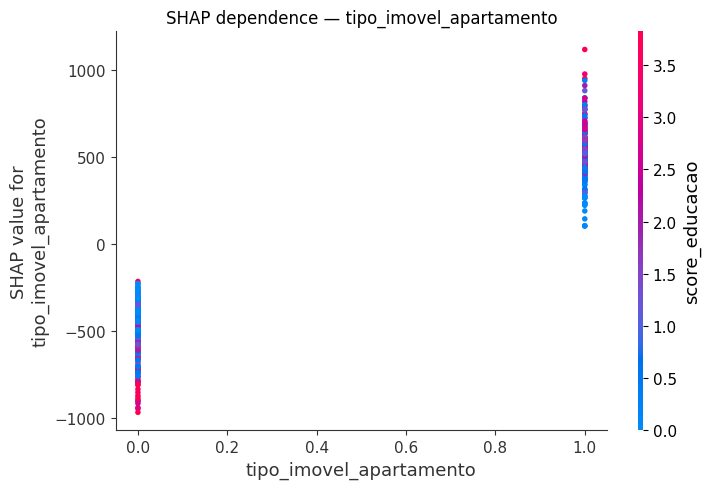

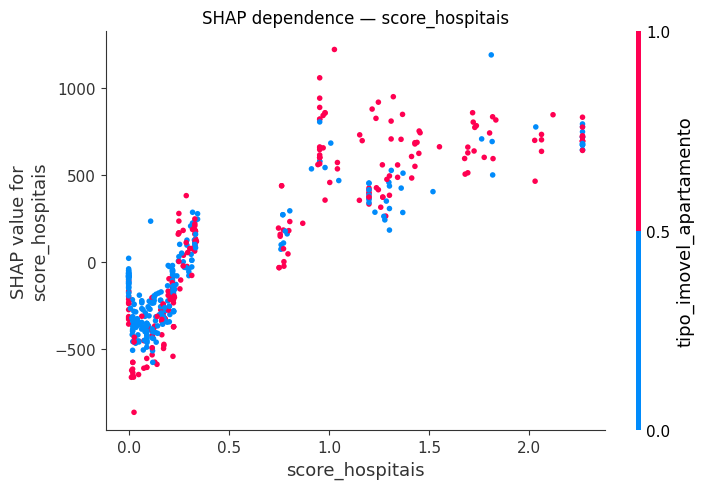

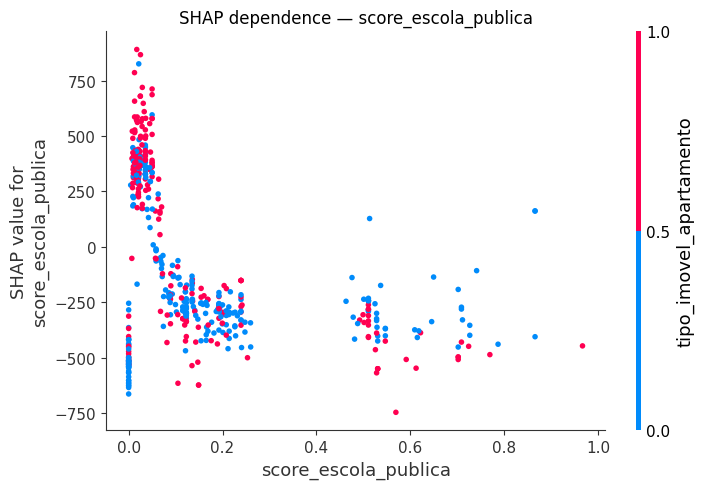

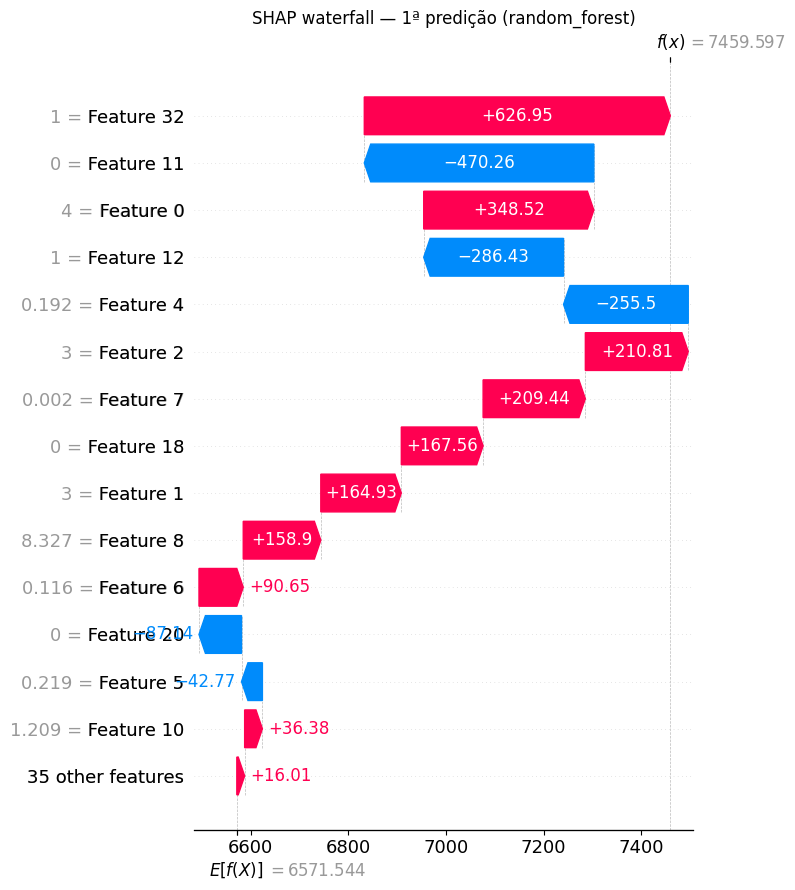

🏃 View run shap_random_forest at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604/runs/201525f3b6fc4c028fc20a0e6a162787
🧪 View experiment at: https://dbc-ed602b14-1f14.cloud.databricks.com/ml/experiments/812916905475604
Análise SHAP concluída e logada no MLflow.


In [38]:
# === Análise SHAP ===
import shap
from pathlib import Path
from tempfile import mkdtemp

# Seleciona o melhor modelo tree-based para SHAP (mais rápido)
MODELOS_TREE = {'random_forest', 'hist_gradient_boosting', 'lightgbm', 'catboost'}
N_BACKGROUND = 300
N_EXPLAIN = 500

tree_available = MODELOS_TREE & set(modelos_treinados.keys())
if tree_available:
    modelo_shap_nome = min(tree_available, key=lambda n: metricas_dict[n]['rmse'])
else:
    modelo_shap_nome = melhor_modelo

print(f'Modelo selecionado para SHAP: {modelo_shap_nome}')

pipeline = modelos_treinados[modelo_shap_nome]
modelo_shap = pipeline.named_steps['modelo']
preprocessor = pipeline.named_steps['preprocessador']

# Pré-processa X_test
X_test_pre = preprocessor.transform(X_test)

# Extrai nomes das features após transformação
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
nomes_features_shap = list(NUMERIC_FEATURES) + list(cat_feature_names)
print(f'Features: {len(nomes_features_shap)} ({len(NUMERIC_FEATURES)} num + {len(cat_feature_names)} cat)')
X_ex_shap = X_test_pre[:N_EXPLAIN] if len(X_test_pre) > N_EXPLAIN else X_test_pre
print(f'Features: {len(nomes_features_shap)}, amostras SHAP: {len(X_ex_shap)}')

# Computa SHAP values
if modelo_shap_nome in MODELOS_TREE:
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_ex_shap)
else:
    background = X_test_pre[:N_BACKGROUND]
    explainer = shap.PermutationExplainer(modelo_shap.predict, background)
    shap_values = explainer(X_ex_shap)

# Importância global (mean |SHAP|)
if shap_values.ndim == 3:
    shap_imp = np.abs(shap_values).mean(axis=(0, 1))
elif shap_values.ndim == 2:
    shap_imp = np.abs(shap_values).mean(axis=0)
else:
    shap_imp = np.abs(shap_values).mean(axis=0)

importancia_shap = pd.Series(shap_imp, index=nomes_features_shap).sort_values(ascending=False)
display(importancia_shap.head(20))

# --- Visualizações ---
tmpdir = Path(mkdtemp())

# 1. Summary beeswarm
shap.summary_plot(
    shap_values, X_ex_shap,
    feature_names=nomes_features_shap,
    show=False, max_display=20,
)
plt.title(f'SHAP — impacto por feature ({modelo_shap_nome})')
plt.tight_layout()
plt.savefig(tmpdir / f'shap_summary_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Bar plot
shap.summary_plot(
    shap_values, X_ex_shap,
    feature_names=nomes_features_shap,
    plot_type='bar', show=False, max_display=20,
)
plt.title(f'SHAP bar — impacto médio ({modelo_shap_nome})')
plt.tight_layout()
plt.savefig(tmpdir / f'shap_bar_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Dependence plot (top 3 features)
for feat in importancia_shap.index[:3]:
    shap.dependence_plot(
        feat, shap_values, X_ex_shap,
        feature_names=nomes_features_shap, show=False,
    )
    plt.title(f'SHAP dependence — {feat}')
    plt.tight_layout()
    plt.savefig(tmpdir / f'shap_dependence_{feat}_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
    plt.show()

# 4. Waterfall plot (first prediction)
if modelo_shap_nome in MODELOS_TREE:
    exp = explainer(X_ex_shap[:1])
    shap.waterfall_plot(exp[0], max_display=15, show=False)
    plt.title(f'SHAP waterfall — 1ª predição ({modelo_shap_nome})')
    plt.tight_layout()
    plt.savefig(tmpdir / f'shap_waterfall_{modelo_shap_nome}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Log no MLflow
mlflow.start_run(run_name=f'shap_{modelo_shap_nome}', nested=True)
try:
    mlflow.set_tag('modelo_shap', modelo_shap_nome)
    for feat, imp in importancia_shap.head(30).items():
        mlflow.log_metric(f'shap_{feat}', float(imp))
    for f in tmpdir.glob('shap_*'):
        mlflow.log_artifact(str(f))
finally:
    mlflow.end_run()

print('Análise SHAP concluída e logada no MLflow.')


## Exemplos de previsão no conjunto de teste

In [48]:
features_list = [x.strip() for x in features[0].split(',')]
features_list

['banheiros',
 'vagas',
 'quartos',
 'score_escola_privada',
 'score_escola_publica',
 'score_hospitais',
 'score_mercado',
 'score_farmacia',
 'score_parque',
 'score_seguranca',
 'score_educacao',
 'tipo_imovel',
 'bairro']

In [ ]:

melhor_modelo = metricas_df["rmse"].idxmin()
modelo_final = modelos_treinados[melhor_modelo]
pred_test = modelo_final.predict(X_test)

exemplos = pd_joinville.loc[X_test.index, features_list + [TARGET] + ["url"]
].copy()
exemplos["preco_previsto"] = pred_test.round(0).astype(int)
exemplos["erro_abs"] = (exemplos[f"{TARGET}"] - exemplos["preco_previsto"]).abs()
exemplos["erro_pct"] = (exemplos["erro_abs"] / exemplos[f"{TARGET}"] * 100).round(1)

exemplos.sort_values("erro_pct").tail(100)

In [ ]:
faixas_erro = [0, 10, 20, 30, 50, 100, np.inf]
valor_acumulado = 0
for i in range(len(faixas_erro)-1):
    lower = faixas_erro[i]
    upper = faixas_erro[i+1]
    count_in_faixa = exemplos[(exemplos['erro_pct'] > lower) & (exemplos['erro_pct'] <= upper)].shape[0]
    pct_in_faixa = count_in_faixa / exemplos.shape[0] * 100
    valor_acumulado += pct_in_faixa
    print(f"Erro entre {lower}% e {upper}%: {count_in_faixa} exemplos ({pct_in_faixa:.1f}%) | Acumulado: {valor_acumulado:.1f}%")
print(f"Total acumulado: {valor_acumulado:.1f}%")

Erro entre 0% e 10%: 1000 exemplos (37.6%) | Acumulado: 37.6%
Erro entre 10% e 20%: 600 exemplos (22.6%) | Acumulado: 60.2%
Erro entre 20% e 30%: 322 exemplos (12.1%) | Acumulado: 72.3%
Erro entre 30% e 50%: 310 exemplos (11.7%) | Acumulado: 84.0%
Erro entre 50% e 100%: 189 exemplos (7.1%) | Acumulado: 91.1%
Erro entre 100% e inf%: 233 exemplos (8.8%) | Acumulado: 99.9%
Total acumulado: 99.9%


In [ ]:
dados_bairro = exemplos[exemplos['bairro'].isin(['centro'])].sort_values("erro_pct").tail(50)
for i in range(50):
    print(dados_bairro.iloc[i]['url'])
    print(f"Bairro: {dados_bairro.iloc[i]['bairro']} | Tipo: {dados_bairro.iloc[i]['tipo_imovel']}")
    print(f"Valor real: R$ {dados_bairro.iloc[i][TARGET]:,.0f} | Previsto: R$ {dados_bairro.iloc[i]['preco_previsto']:,.0f} | Erro: {dados_bairro.iloc[i]['erro_pct']}%")


https://www.chavesnamao.com.br/imovel/apartamento-a-venda-3-quartos-com-garagem-sc-joinville-centro-RS1702367/id-27797522/
Bairro: centro | Tipo: apartamento
Valor real: R$ 12,247 | Previsto: R$ 10,736 | Erro: 12.3%
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-4-quartos-com-garagem-sc-joinville-centro-638m2-RS2880000/id-2815284/
Bairro: centro | Tipo: apartamento
Valor real: R$ 11,429 | Previsto: R$ 10,014 | Erro: 12.4%
https://www.chavesnamao.com.br/imovel/casa-a-venda-3-quartos-com-garagem-sc-joinville-centro-360m2-RS1000000/id-29316985/
Bairro: centro | Tipo: casa
Valor real: R$ 5,291 | Previsto: R$ 5,965 | Erro: 12.7%
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-no-edificio-newport-1376122847
Bairro: centro | Tipo: apartamento
Valor real: R$ 10,984 | Previsto: R$ 12,459 | Erro: 13.4%
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-3-quartos-com-garagem-sc-joinville-centro-189m2-RS1750000/id-39496929/
Bairro: centro | Tipo: apartamento
Val

<Axes: title={'center': 'Erro percentual médio por bairro'}, ylabel='bairro,tipo_imovel'>

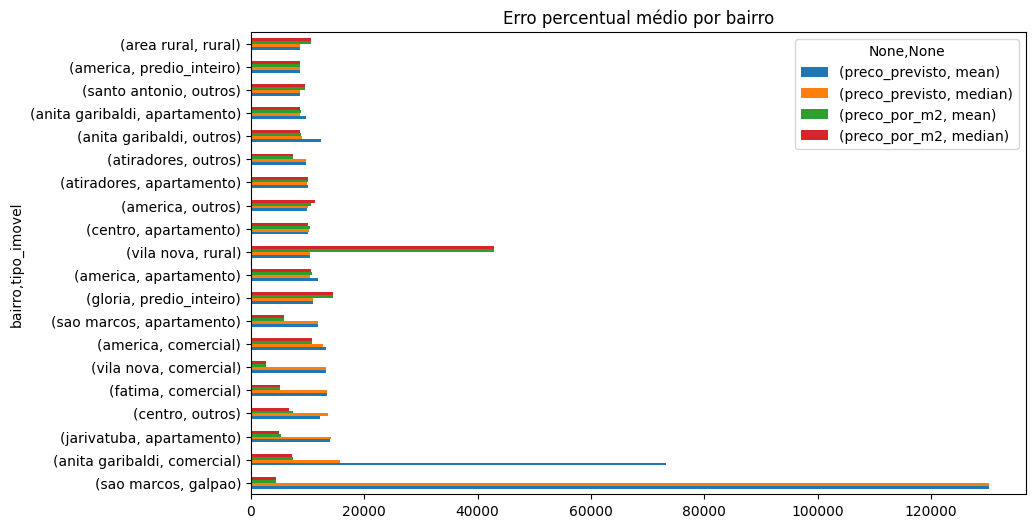

In [ ]:
grouped_preco_previsto_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"preco_previsto": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "preco_por_m2": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"), ascending=False).head(20).plot(kind="barh", figsize=(10, 6), title="Erro percentual médio por bairro")

In [ ]:
grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"))

preco_previsto           preco_por_m2             
                                      mean    median         mean       median
bairro          tipo_imovel                                                   
itinga          terreno        1313.666667     677.0   931.536738   940.860215
santa catarina  terreno         999.200000     688.0   669.331010   822.368421
rio bonito      terreno         961.000000     961.0   380.733945   380.733945
itaum           terreno        1473.500000    1077.0   812.947098   823.617647
jardim paraiso  terreno        1079.000000    1079.0   224.965012   224.965012
...                                    ...       ...          ...          ...
fatima          comercial     13443.000000   13443.0  5084.745763  5084.745763
centro          outros        12256.666667   13583.0  7424.831777  6666.666667
jarivatuba      apartamento   14055.500000   14134.5  5323.264411  5026.679842
anita garibaldi comercial     73250.500000   15745.0  7483.479079  7273.107890
sao marcos      galpao       130179.000000  130179.0  4375.000000  4375.000000

[149 rows x 4 columns]

<Axes: title={'center': 'Erro percentual médio por bairro'}, ylabel='bairro,tipo_imovel'>

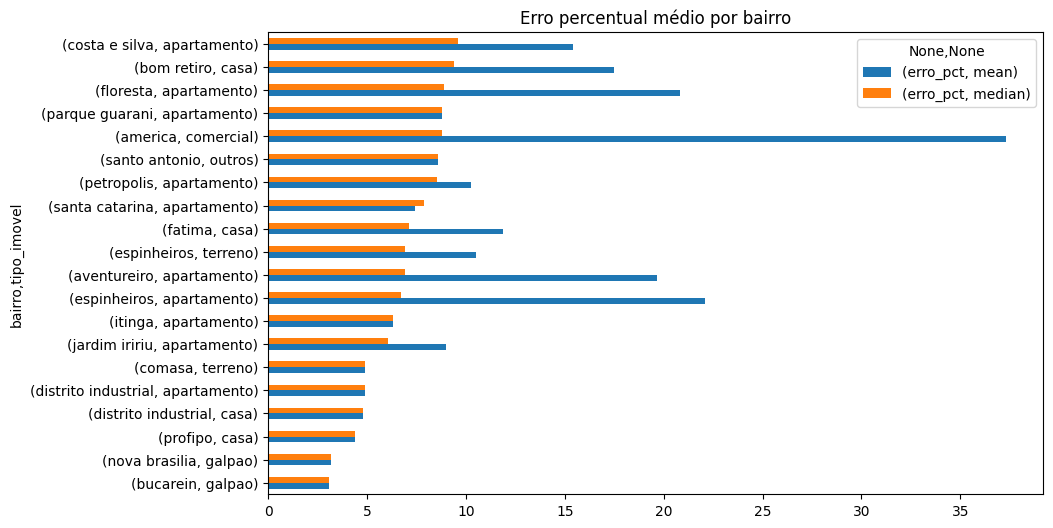

In [ ]:
grouped_erro_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"erro_pct": ["mean", "median"]})#.sort_values("erro_pct", ascending=False)

grouped_erro_bairro.sort_values(("erro_pct", "median"), ascending=True).head(20).plot(kind="barh", figsize=(10, 6), title="Erro percentual médio por bairro")

In [ ]:
bairros = df_modelo["bairro"].unique()
tipos = df_modelo["tipo_imovel"].unique()

tipos = ["apartamento"]  # Foco nos tipos mais comuns para evitar ruído de poucos exemplos

metrics_bairro = {}

for bairro in bairros:
    for tipo in tipos:
        try:
            print(f"{bairro} - {tipo} - Métricas por bairro:")
            previsao_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"preco_previsto"]
            valor_verdadeiro_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"{TARGET}"]
            metrics_bairro[(bairro, tipo)] = metricas(bairro, valor_verdadeiro_bairro, previsao_bairro)
        except Exception as e:
            print(f"Erro ao processar o bairro {bairro}: {e}")
    

joao costa - apartamento - Métricas por bairro:
joao costa: RMSE=R$ 1,124 | MAE=R$ 869 | MAPE=21.3% | R²=-0.277
comasa - apartamento - Métricas por bairro:
comasa: RMSE=R$ 1,579 | MAE=R$ 1,124 | MAPE=53.2% | R²=0.264
gloria - apartamento - Métricas por bairro:
gloria: RMSE=R$ 1,916 | MAE=R$ 1,400 | MAPE=18.1% | R²=0.536
bom retiro - apartamento - Métricas por bairro:
bom retiro: RMSE=R$ 1,421 | MAE=R$ 1,123 | MAPE=19.8% | R²=0.054
paranaguamirim - apartamento - Métricas por bairro:
paranaguamirim: RMSE=R$ 1,364 | MAE=R$ 980 | MAPE=25.7% | R²=-0.430
itaum - apartamento - Métricas por bairro:
itaum: RMSE=R$ 1,160 | MAE=R$ 911 | MAPE=18.2% | R²=-0.009
pirabeiraba - apartamento - Métricas por bairro:
pirabeiraba: RMSE=R$ 2,708 | MAE=R$ 2,104 | MAPE=24.9% | R²=0.410
centro - apartamento - Métricas por bairro:
centro: RMSE=R$ 3,098 | MAE=R$ 1,704 | MAPE=19.9% | R²=0.508
bucarein - apartamento - Métricas por bairro:
bucarein: RMSE=R$ 1,724 | MAE=R$ 1,400 | MAPE=24.3% | R²=0.372
petropolis - a

In [ ]:
metrics_bairro_df = pd.DataFrame(metrics_bairro).T.sort_values("mape", ascending=True)
metrics_bairro_df.head(40)

,,rmse,mae,mape,r2
distrito industrial,apartamento,263.733333,263.733333,4.928428,NaN
itinga,apartamento,285.196078,285.196078,6.323913,NaN
santa catarina,apartamento,507.433504,428.028622,7.444010,0.717706
parque guarani,apartamento,386.000000,386.000000,8.822857,NaN
jardim iririu,apartamento,615.212668,444.126480,9.018700,0.361500
petropolis,apartamento,676.195985,560.474731,10.235980,0.000615
iririu,apartamento,913.498411,665.876465,11.193223,0.414867
guanabara,apartamento,979.345677,862.860012,14.564142,0.002233
vila nova,apartamento,920.500770,779.004442,14.576611,0.216164
costa e silva,apartamento,1209.152012,924.055549,15.397232,0.291479


# Treinando o melhor modelo com todos os dados e fazendo a predicao

In [ ]:
def treinar_pipeline_final(nome, estimador, X_tr, y_tr):
    pipe = Pipeline([
        ("preprocessador", criar_preprocessador()),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe

In [ ]:
import numpy as np
import pandas as pd
from typing import Tuple

def clean_target(X, y, max_abs_value: float = 1e200) -> Tuple:
    """Limpa y removendo NaN e Inf e alinha X com y.

    - Converte y para Series numérica (coerce errors -> NaN).
    - Marca valores NaN, Inf ou abs(y) > max_abs_value como inválidos.
    - Remove as linhas correspondentes em X e y mantendo tipo de X (np.ndarray or pd.DataFrame).

    Retorna: X_clean, y_clean
    """
    # preparar y
    y_ser = pd.to_numeric(pd.Series(y).copy(), errors="coerce")

    # preparar X para alinhamento (converter em DataFrame temporariamente)
    X_is_df = isinstance(X, pd.DataFrame)
    try:
        X_df = X.copy() if X_is_df else pd.DataFrame(X)
    except Exception:
        X_df = pd.DataFrame(np.asarray(X))

    # alinhar índices: use interseção de índices se possível
    common_index = X_df.index.intersection(y_ser.index)
    if len(common_index) == 0:
        min_len = min(len(X_df), len(y_ser))
        if len(X_df) != len(y_ser):
            print(f"clean_target: índices diferentes, truncando X/y para {min_len}")
        X_df = X_df.iloc[:min_len].copy()
        y_ser = y_ser.iloc[:min_len].copy()
    else:
        X_df = X_df.loc[common_index].copy()
        y_ser = y_ser.loc[common_index].copy()

    # detectar infinitos e valores absurdos após alinhamento
    bad_mask = y_ser.isna() | np.isinf(y_ser) | (y_ser.abs() > max_abs_value)
    n_bad = int(bad_mask.sum())
    if n_bad > 0:
        print(f"clean_target: removendo {n_bad} observações com NaN/Inf/valores extremos de y")

    keep_mask = ~bad_mask
    X_clean = X_df.loc[keep_mask].copy()
    y_clean = y_ser.loc[keep_mask].copy().reset_index(drop=True)

    # devolver no mesmo tipo de X
    if not X_is_df:
        X_out = X_clean.values
    else:
        X_out = X_clean

    return X_out, y_clean


In [ ]:
columns = [TARGET] + NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [ ]:
pd_joinville_limpo = pd_joinville[features_list + [TARGET]].dropna()
joinville_completo = pd_joinville_limpo.copy()
X_joinville_completo = joinville_completo[features_list].copy()
y_joinville_completo = joinville_completo[TARGET].copy()

melhor_modelo = metricas_df["rmse"].idxmin()
melhor_modelo

NameError: name 'features_list' is not defined

In [ ]:
X_joinville_completo, y_joinville_completo = clean_target(X_joinville_completo, y_joinville_completo)

clean_target: removendo 12 observações com NaN/Inf/valores extremos de y


In [ ]:
X_joinville_completo.shape, y_joinville_completo.shape

((26840, 13), (26840,))

In [ ]:
modelo_final = treinar_pipeline_final("modelo_final", best_models[melhor_modelo], X_joinville_completo, y_joinville_completo)   

In [ ]:
pd_joinville.columns

Index(['url', 'titulo', 'metragem', 'banheiros', 'vagas', 'quartos',
       'valor_imovel', 'condominio', 'endereco', 'iptu', 'descricao',
       'data_criacao', 'caracteristicas', 'fotos', 'link_maps', 'fonte', 'rua',
       'numero', 'bairro', 'cidade', 'estado', 'cep', 'dias_publicacao',
       'tipo_imovel', 'lat', 'lng', 'preco_por_m2', 'faixa', 'p25_bairro',
       'p50_bairro', 'p75_bairro', 'desvio_mediana', 'score_escola_privada',
       'score_escola_publica', 'score_hospitais', 'score_mercado',
       'score_farmacia', 'score_parque', 'score_seguranca', 'score_educacao'],
      dtype='object')

In [ ]:
dados_completo_final = X_joinville_completo.copy()

predicao_completa= modelo_final.predict(X_joinville_completo)
dados_completo_final["predicao_metro_quadrado"] = predicao_completa.round(0).astype(int)

dados_completo_final['url'] = pd_joinville.loc[X_joinville_completo.index, 'url']
dados_completo_final['metragem'] = pd_joinville.loc[X_joinville_completo.index, 'metragem']
dados_completo_final['valor_imovel'] = pd_joinville.loc[X_joinville_completo.index, 'valor_imovel']
dados_completo_final['valor_imovel_previsto'] = dados_completo_final['metragem'] * dados_completo_final['predicao_metro_quadrado']

dados_completo_final['metro_quadrado_real'] = dados_completo_final['valor_imovel'] /dados_completo_final['metragem']


dados_completo_final["erro_abs"] = (dados_completo_final["metro_quadrado_real"] - dados_completo_final["predicao_metro_quadrado"]).abs()
dados_completo_final["erro_pct"] = (dados_completo_final["erro_abs"] / dados_completo_final["metro_quadrado_real"] * 100).round(1)



dados_completo_final.sort_values("erro_pct")



,banheiros,vagas,quartos,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,...,tipo_imovel,bairro,predicao_metro_quadrado,url,metragem,valor_imovel,valor_imovel_previsto,metro_quadrado_real,erro_abs,erro_pct
11498,1,1,2,0.275115,0.259719,2.087665e-02,1.070919,1.045411,4.017573e+00,6.953016e-01,...,casa,vila nova,5384,https://www.chavesnamao.com.br/imovel/casa-a-v...,65.0,350000.0,3.499600e+05,5384.615385,0.615385,0.0
14373,4,3,3,1.361771,0.207995,1.761333e-01,0.752768,0.000459,7.360451e+00,4.731594e-01,...,casa,boa vista,5901,https://www.chavesnamao.com.br/imovel/casa-em-...,182.0,1074000.0,1.073982e+06,5901.098901,0.098901,0.0
19131,1,1,3,0.000000,0.000000,7.550232e-255,0.000000,0.000000,2.817300e-251,8.190158e-203,...,apartamento,gloria,6695,https://sc.olx.com.br/norte-de-santa-catarina/...,87.0,582198.0,5.824650e+05,6691.931034,3.068966,0.0
26861,1,1,2,0.000000,0.000000,5.990097e-195,0.000000,0.000000,6.248962e-192,1.958121e-154,...,casa,floresta,5558,https://sc.olx.com.br/norte-de-santa-catarina/...,63.0,350000.0,3.501540e+05,5555.555556,2.444444,0.0
5093,2,3,3,4.484458,0.023566,1.802725e+00,0.190783,0.160272,2.414587e+01,1.693070e+00,...,apartamento,centro,9258,https://www.chavesnamao.com.br/imovel/apartame...,161.0,1490000.0,1.490538e+06,9254.658385,3.341615,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25028,1,2,2,0.248905,0.195757,4.060903e-02,0.689123,0.727692,3.339887e+00,1.218343e+00,...,casa,aventureiro,4573,https://sc.olx.com.br/norte-de-santa-catarina/...,376200.0,375000.0,1.720363e+09,0.996810,4572.003190,458663.4
2012,0,0,0,0.032333,0.085795,1.265423e-01,0.176892,0.000421,4.073609e-01,4.682080e-01,...,terreno,sao marcos,227898,https://www.vivareal.com.br/imovel/lote-terren...,24817.0,1200000.0,5.655745e+09,48.353951,227849.646049,471212.1
6331,0,0,0,0.032333,0.085795,1.265423e-01,0.176892,0.000421,4.073609e-01,4.682080e-01,...,terreno,sao marcos,227898,https://www.chavesnamao.com.br/imovel/terreno-...,32483.0,945000.0,7.402811e+09,29.092141,227868.907859,783266.2
6473,0,0,0,0.032333,0.085795,1.265423e-01,0.176892,0.000421,4.073609e-01,4.682080e-01,...,terreno,sao marcos,227898,https://www.chavesnamao.com.br/imovel/terreno-...,30767.0,895000.0,7.011738e+09,29.089609,227868.910391,783334.4


In [ ]:
apartamentos = dados_completo_final[dados_completo_final["tipo_imovel"] == "apartamento"].dropna().sort_values("erro_pct")

In [ ]:
apartamentos_limite = apartamentos[apartamentos['erro_pct'] < 100]
for i in range(len(apartamentos_limite)):
    print("---")
    print(apartamentos_limite.iloc[i]['url'])
    print(f"Bairro: {apartamentos_limite.iloc[i]['bairro']} | Tipo: {apartamentos_limite.iloc[i]['tipo_imovel']}")
    print(f"Valor real: R$ {apartamentos_limite.iloc[i]["metro_quadrado_real"]} | Previsto: R$ {apartamentos_limite.iloc[i]['predicao_metro_quadrado']} | Erro: {apartamentos_limite.iloc[i]['erro_pct']}%")
    print(f"Valor do imovel real: R$ {apartamentos_limite.iloc[i]["valor_imovel"]} | Previsto: R$ {apartamentos_limite.iloc[i]['valor_imovel_previsto']} |")
    print(f"Metragem {apartamentos_limite.iloc[i]['metragem']} ")
    print("---")

---
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-semi-mobiliado-2-quartos-aventureiro-1477490378
Bairro: aventureiro | Tipo: apartamento
Valor real: R$ 5800.0 | Previsto: R$ 5802 | Erro: 0.0%
Valor do imovel real: R$ 290000.0 | Previsto: R$ 290100.0 |
Metragem 50.0 
---
---
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-itaum-48m2-RS301359/id-41796793/
Bairro: itaum | Tipo: apartamento
Valor real: R$ 6278.3125 | Previsto: R$ 6280 | Erro: 0.0%
Valor do imovel real: R$ 301359.0 | Previsto: R$ 301440.0 |
Metragem 48.0 
---
---
https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-em-rua-expedicionario-holz-atiradores-joinville-sc-1498499462
Bairro: atiradores | Tipo: apartamento
Valor real: R$ 10983.730964467006 | Previsto: R$ 10979 | Erro: 0.0%
Valor do imovel real: R$ 2163795.0 | Previsto: R$ 2162863.0 |
Metragem 197.0 
---
---
https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc

In [ ]:
faixas_erro = [0, 10, 20, 30, 50, 100, np.inf]
valor_acumulado = 0
for i in range(len(faixas_erro)-1):
    lower = faixas_erro[i]
    upper = faixas_erro[i+1]
    count_in_faixa = apartamentos[(apartamentos['erro_pct'] > lower) & (apartamentos['erro_pct'] <= upper)].shape[0]
    pct_in_faixa = count_in_faixa / apartamentos.shape[0] * 100
    valor_acumulado += pct_in_faixa
    print(f"Erro entre {lower}% e {upper}%: {count_in_faixa} exemplos ({pct_in_faixa:.1f}%) | Acumulado: {valor_acumulado:.1f}%")
print(f"Total acumulado: {valor_acumulado:.1f}%")

Erro entre 0% e 10%: 4965 exemplos (42.3%) | Acumulado: 42.3%
Erro entre 10% e 20%: 3131 exemplos (26.7%) | Acumulado: 68.9%
Erro entre 20% e 30%: 1581 exemplos (13.5%) | Acumulado: 82.4%
Erro entre 30% e 50%: 1116 exemplos (9.5%) | Acumulado: 91.9%
Erro entre 50% e 100%: 625 exemplos (5.3%) | Acumulado: 97.2%
Erro entre 100% e inf%: 299 exemplos (2.5%) | Acumulado: 99.8%
Total acumulado: 99.8%


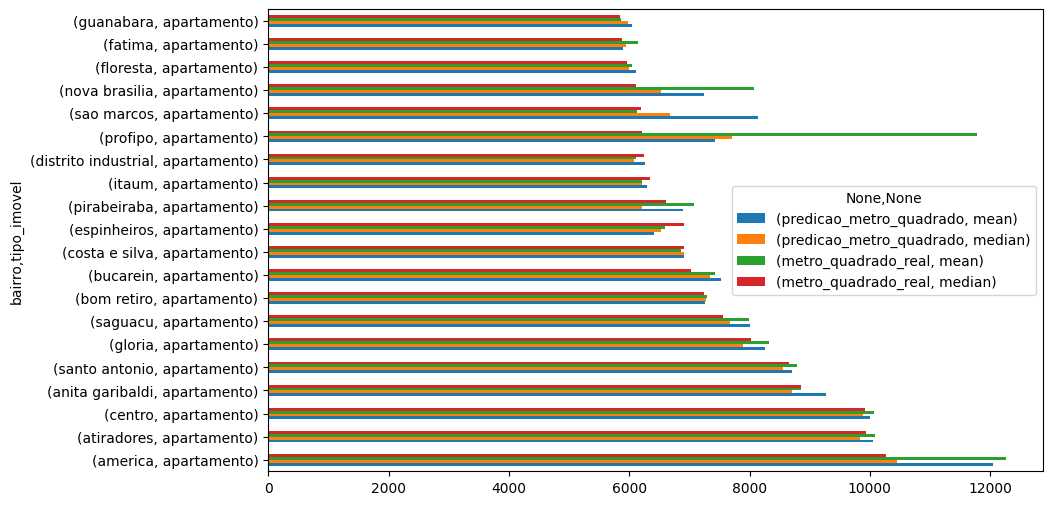

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
grouped_preco_previsto_bairro = apartamentos.groupby(["bairro", "tipo_imovel"]).aggregate({"predicao_metro_quadrado": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "metro_quadrado_real": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("metro_quadrado_real", "median"), ascending=False).head(20).plot(kind="barh", figsize=(10, 6),)
plt.show()

In [ ]:
grouped_preco_previsto_bairro.sort_values(("metro_quadrado_real", "median"), ascending=False)

predicao_metro_quadrado           \
                                                   mean   median   
bairro              tipo_imovel                                    
america             apartamento            12045.942512  10455.0   
atiradores          apartamento            10056.085479   9836.0   
centro              apartamento            10009.741543   9885.0   
anita garibaldi     apartamento             9276.360248   8704.0   
santo antonio       apartamento             8709.381679   8556.0   
gloria              apartamento             8256.343874   7895.0   
saguacu             apartamento             8005.535211   7671.0   
bom retiro          apartamento             7263.794118   7276.0   
bucarein            apartamento             7519.372624   7349.0   
costa e silva       apartamento             6907.096883   6907.0   
espinheiros         apartamento             6411.428571   6532.0   
pirabeiraba         apartamento             6901.661290   6216.0   
itaum               apartamento             6292.583333   6218.0   
distrito industrial apartamento             6254.653846   6078.0   
profipo             apartamento             7431.666667   7713.0   
sao marcos          apartamento             8146.194444   6686.0   
nova brasilia       apartamento             7247.323529   6527.0   
floresta            apartamento             6106.509302   6000.0   
fatima              apartamento             5898.653061   5952.0   
guanabara           apartamento             6049.744681   5985.5   
iririu              apartamento             5852.010870   5738.0   
petropolis          apartamento             6035.235294   5981.5   
jardim sofia        apartamento             5785.692308   5633.5   
aventureiro         apartamento             5678.411392   5634.0   
vila nova           apartamento             5829.685714   5715.0   
comasa              apartamento             5928.847826   5944.0   
boa vista           apartamento             5883.706667   5628.0   
joao costa          apartamento             5102.873786   5175.0   
jardim iririu       apartamento             5456.966102   5451.0   
santa catarina      apartamento             5333.677419   5055.0   
parque guarani      apartamento             5243.600000   4761.0   
jarivatuba          apartamento             9866.450000   5516.0   
adhemar garcia      apartamento             4787.307692   4720.0   
itinga              apartamento             4571.333333   4697.0   
boehmerwald         apartamento             6597.289474   7398.0   
morro do meio       apartamento             4837.666667   4796.0   
paranaguamirim      apartamento             4699.037037   4570.0   
jardim paraiso      apartamento             4380.714286   3885.0   
ulysses guimaraes   apartamento             3763.000000   3763.0   

                                metro_quadrado_real                
                                               mean        median  
bairro              tipo_imovel                                    
america             apartamento        12267.025924  10275.366013  
atiradores          apartamento        10078.935257   9941.230159  
centro              apartamento        10067.933771   9913.419913  
anita garibaldi     apartamento         8863.188895   8857.142857  
santo antonio       apartamento         8783.558639   8648.648649  
gloria              apartamento         8316.829160   8031.007107  
saguacu             apartamento         7991.392683   7555.555556  
bom retiro          apartamento         7292.123754   7247.237392  
bucarein            apartamento         7421.535426   7032.758621  
costa e silva       apartamento         6863.936072   6917.261538  
espinheiros         apartamento         6601.622942   6909.625000  
pirabeiraba         apartamento         7080.322685   6614.979167  
itaum               apartamento         6216.789955   6340.744681  
distrito industrial apartamento         6110.577796   6252.062802  
profipo            

Quantidade de apartamentos analisados: 11746

Resumo dos resíduos por m² para apartamentos:
            residuo    residuo_pct
count  1.174600e+04   11746.000000
mean   6.105396e+01     152.898126
std    3.903770e+04    4027.852633
min   -4.139892e+06     -91.997600
25%   -8.790096e+02      -9.546657
50%    8.514622e+01       1.141569
75%    1.143192e+03      17.377961
max    3.519911e+05  246423.609375

Métricas do modelo para apartamentos (por m²):
MAE: R$ 2,076 por m²
RMSE: R$ 39,036 por m²
Median AE: R$ 1,007 por m²
R²: 0.1178
Explained variance: 0.1178
Baseline MAE (média): R$ 2,824 por m²
Apartamentos com erro absoluto <= 5%: 22.3%
Apartamentos com erro absoluto <= 10%: 42.3%
Apartamentos com erro absoluto <= 20%: 69.1%
Apartamentos com erro absoluto <= 30%: 82.6%
Apartamentos com erro absoluto <= 50%: 92.1%


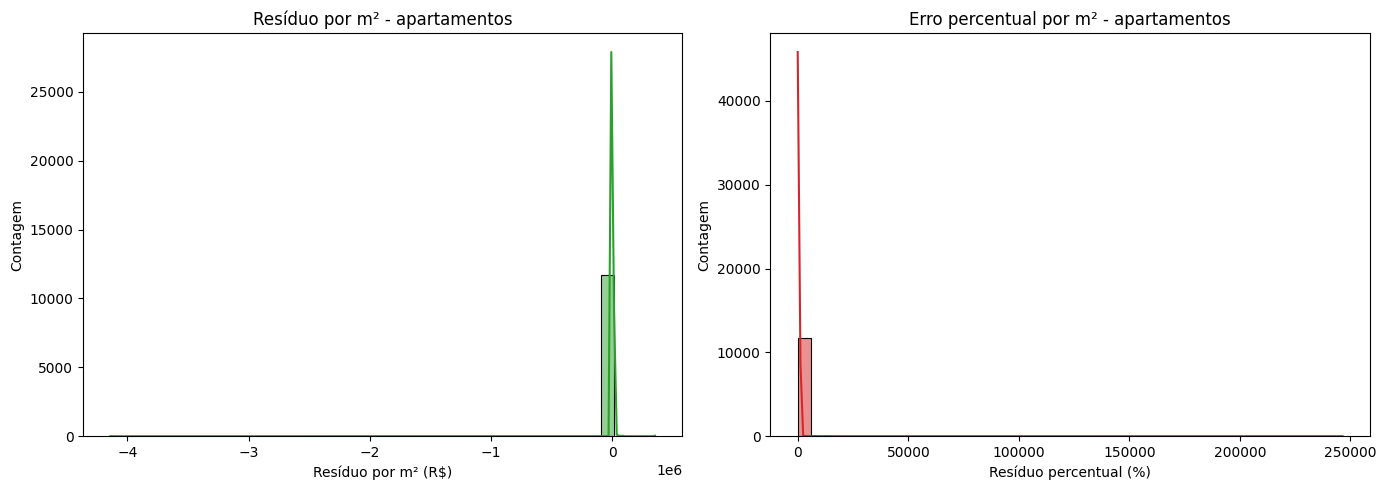

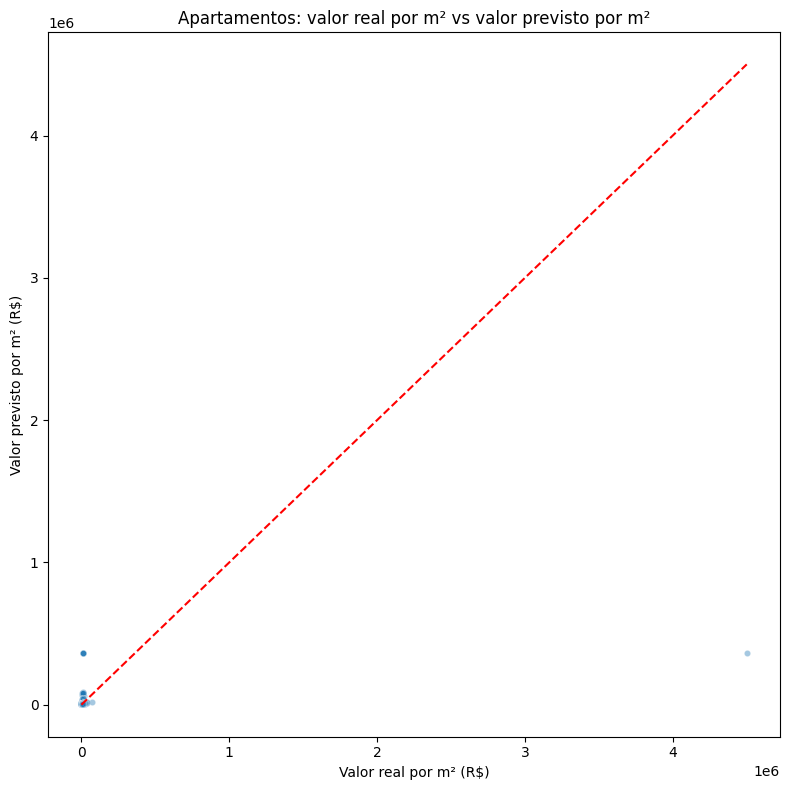


Top 10 bairros com menor mediana de erro percentual em apartamentos:
                 mediana_residuo_pct          mae  contagem
bairro                                                     
espinheiros                -5.317522   688.631697        28
gloria                     -1.972560  1347.411849       506
centro                     -1.004400  1865.727653       739
itaum                      -0.771371  1001.157084       120
anita garibaldi            -0.661725  1718.785421      1610
costa e silva              -0.455691   996.067655      1187
sao marcos                 -0.071436  2518.426013        36
pirabeiraba                 0.000714  1456.234257        62
santo antonio               0.018286  1574.908770       917
bom retiro                  0.162167  1046.605025       408

Top 10 bairros com maior mediana de erro percentual em apartamentos:
                   mediana_residuo_pct          mae  contagem
bairro                                                       
boa vista       

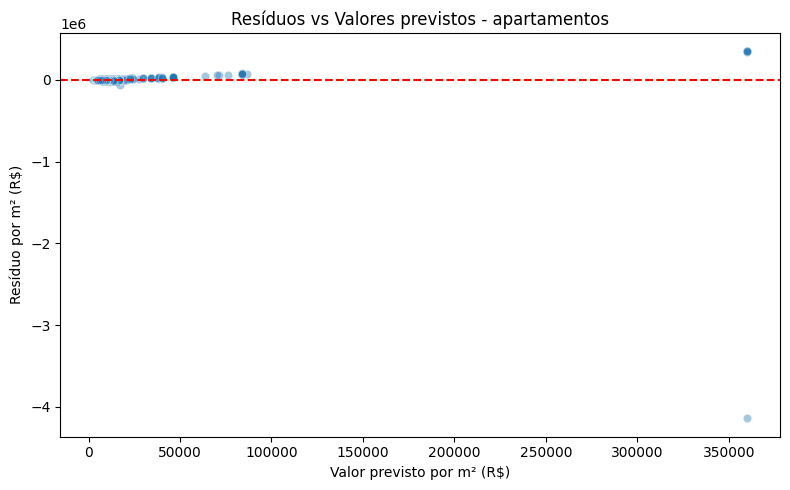


2. Homocedasticidade (Variância Constante)
Variância dos resíduos por quintil de valor previsto:
fitted_bin
(2437.999, 6578.0]     1.347900e+06
(6578.0, 7558.0]       2.111890e+06
(7558.0, 8800.0]       3.209367e+06
(8800.0, 10197.0]      4.938209e+06
(10197.0, 360108.0]    7.614230e+09
Name: residuo, dtype: float64
Comentário: variâncias muito distintas; há indícios de heterocedasticidade.


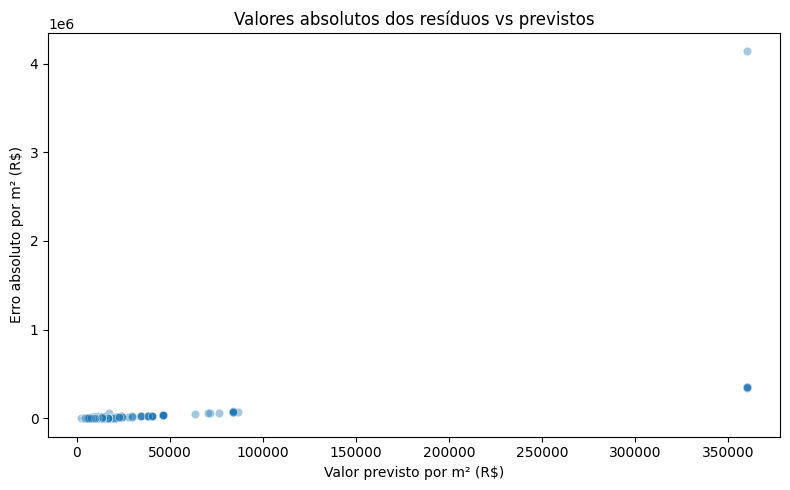


3. Normalidade dos Resíduos


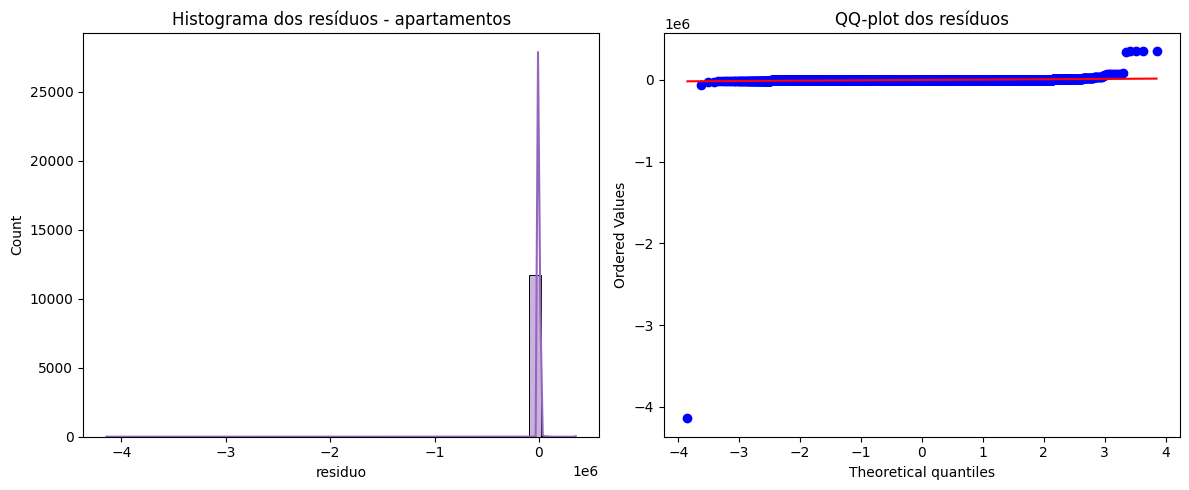

Shapiro-Wilk: estatística=0.1889, p-value=0.0000
Comentário: rejeita-se normalidade dos resíduos.

4. Independência dos Erros (Ausência de Autocorrelação)
Autocorrelação de lag 1 dos resíduos: 0.0012
Estatística de Durbin-Watson aproximada: 1.9977
Comentário: não há forte evidência de autocorrelação nos resíduos.

5. Identificação de Outliers e Pontos de Influência
Número de outliers extremos (|z| > 3): 6
Primeiros outliers extremos:
        bairro  metragem  metro_quadrado_real  predicao_metro_quadrado  \
7578   america     593.0         8.263069e+03                   360108   
9000   america       1.0         4.500000e+06                   360108   
13919  america     180.0         1.100000e+04                   360108   
15837  america     302.0         8.278146e+03                   360108   
16074  america     332.0         1.265060e+04                   360108   
16201  america     308.0         8.116883e+03                   360108   

            residuo  residuo_pct  
7578   3

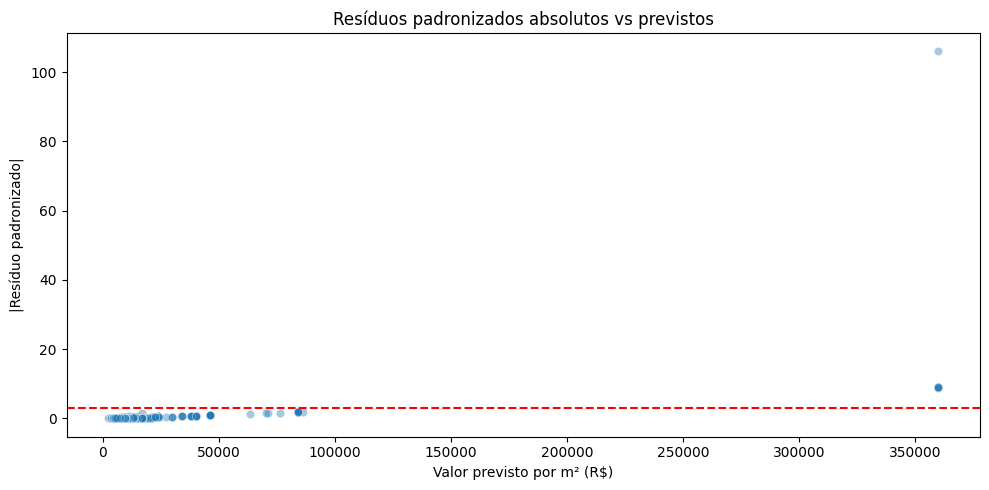

Comentário: existem outliers fortes nos resíduos, o que pode afetar a estabilidade do modelo.

Top 20 apartamentos com maior erro percentual novamente:
                    bairro  metragem  metro_quadrado_real  \
24336               centro   91570.0             3.494594   
947            pirabeiraba  912000.0             3.179825   
23380            vila nova   51000.0             4.980392   
25745              america      35.0             9.142857   
5618         santo antonio   62160.0             7.305148   
6084           aventureiro   60617.0             4.223238   
5729                gloria   62380.0             4.729080   
6019         costa e silva   58000.0             6.691103   
24166             floresta   56310.0             5.416445   
25916        jardim iririu      65.0             4.615385   
6362       anita garibaldi   57530.0             9.658057   
23755           joao costa   54140.0             4.525305   
5798         santo antonio   61930.0             9.2039

In [ ]:
# Análise específica para apartamentos
apartamentos = dados_completo_final[dados_completo_final['tipo_imovel'] == 'apartamento'].copy()
apartamentos = apartamentos[apartamentos['metro_quadrado_real'].notna() & (apartamentos['metro_quadrado_real'] != 0)]

apartamentos['residuo'] = apartamentos['predicao_metro_quadrado'] - apartamentos['metro_quadrado_real']
apartamentos['residuo_pct'] = 100 * apartamentos['residuo'] / apartamentos['metro_quadrado_real']

print('Quantidade de apartamentos analisados:', apartamentos.shape[0])
print('\nResumo dos resíduos por m² para apartamentos:')
print(apartamentos[['residuo', 'residuo_pct']].describe())

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score

y_true_ap = apartamentos['metro_quadrado_real']
y_pred_ap = apartamentos['predicao_metro_quadrado']

mae_ap = mean_absolute_error(y_true_ap, y_pred_ap)
rmse_ap = np.sqrt(mean_squared_error(y_true_ap, y_pred_ap))
r2_ap = r2_score(y_true_ap, y_pred_ap)
medae_ap = median_absolute_error(y_true_ap, y_pred_ap)
evs_ap = explained_variance_score(y_true_ap, y_pred_ap)

baseline_pred_ap = np.full_like(y_true_ap, y_true_ap.mean())
baseline_mae_ap = mean_absolute_error(y_true_ap, baseline_pred_ap)

print('\nMétricas do modelo para apartamentos (por m²):')
print(f'MAE: R$ {mae_ap:,.0f} por m²')
print(f'RMSE: R$ {rmse_ap:,.0f} por m²')
print(f'Median AE: R$ {medae_ap:,.0f} por m²')
print(f'R²: {r2_ap:.4f}')
print(f'Explained variance: {evs_ap:.4f}')
print(f'Baseline MAE (média): R$ {baseline_mae_ap:,.0f} por m²')

for limite in [5, 10, 20, 30, 50]:
    pct = (apartamentos['residuo_pct'].abs() <= limite).mean() * 100
    print(f'Apartamentos com erro absoluto <= {limite}%: {pct:.1f}%')

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(apartamentos['residuo'], bins=40, kde=True, color='C2')
plt.title('Resíduo por m² - apartamentos')
plt.xlabel('Resíduo por m² (R$)')
plt.ylabel('Contagem')

plt.subplot(1, 2, 2)
sns.histplot(apartamentos['residuo_pct'], bins=40, kde=True, color='C3')
plt.title('Erro percentual por m² - apartamentos')
plt.xlabel('Resíduo percentual (%)')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_true_ap, y=y_pred_ap, alpha=0.4, s=20)
plt.plot([y_true_ap.min(), y_true_ap.max()], [y_true_ap.min(), y_true_ap.max()], color='red', linestyle='--')
plt.title('Apartamentos: valor real por m² vs valor previsto por m²')
plt.xlabel('Valor real por m² (R$)')
plt.ylabel('Valor previsto por m² (R$)')
plt.tight_layout()
plt.show()

bairros_ap = apartamentos.groupby('bairro').agg(
    mediana_residuo_pct=('residuo_pct', 'median'),
    mae=('residuo', lambda x: np.mean(np.abs(x))),
    contagem=('residuo_pct', 'size')
).sort_values('mediana_residuo_pct')

print('\nTop 10 bairros com menor mediana de erro percentual em apartamentos:')
print(bairros_ap.head(10))
print('\nTop 10 bairros com maior mediana de erro percentual em apartamentos:')
print(bairros_ap.tail(10))

print('\nTop 20 apartamentos com maior erro percentual:')
print(apartamentos.sort_values('residuo_pct', ascending=False).head(20)[['bairro', 'metragem', 'metro_quadrado_real', 'predicao_metro_quadrado', 'residuo_pct']])

# Diagnóstico de resíduos para apartamentos
residuos = apartamentos['residuo']
preditos = apartamentos['predicao_metro_quadrado']

print('\nDiagnóstico dos resíduos:')
print(f'Média dos resíduos: {residuos.mean():.2f} R$ por m²')
print(f'Desvio padrão dos resíduos: {residuos.std():.2f} R$ por m²')
print(f'Correlação entre resíduos e valores previstos: {residuos.corr(preditos):.4f}')

# 1. Linearidade e média zero
print('\n1. Linearidade e Independência (Média Zero)')
if abs(residuos.mean()) < 0.05 * residuos.std():
    print('Comentário: média dos resíduos está próxima de zero; bom sinal de ausência de viés.')
else:
    print('Comentário: média dos resíduos não está próxima de zero; pode haver viés sistemático.')

plt.figure(figsize=(8, 5))
sns.scatterplot(x=preditos, y=residuos, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs Valores previstos - apartamentos')
plt.xlabel('Valor previsto por m² (R$)')
plt.ylabel('Resíduo por m² (R$)')
plt.tight_layout()
plt.show()

# 2. Homocedasticidade
print('\n2. Homocedasticidade (Variância Constante)')
apartamentos['fitted_bin'] = pd.qcut(preditos, q=5, duplicates='drop')
var_bins = apartamentos.groupby('fitted_bin')['residuo'].var()
print('Variância dos resíduos por quintil de valor previsto:')
print(var_bins)
if var_bins.max() / var_bins.min() > 4:
    print('Comentário: variâncias muito distintas; há indícios de heterocedasticidade.')
else:
    print('Comentário: variâncias relativamente semelhantes; sinal de homocedasticidade.')

plt.figure(figsize=(8, 5))
sns.scatterplot(x=preditos, y=residuos.abs(), alpha=0.4)
plt.title('Valores absolutos dos resíduos vs previstos')
plt.xlabel('Valor previsto por m² (R$)')
plt.ylabel('Erro absoluto por m² (R$)')
plt.tight_layout()
plt.show()

# 3. Normalidade dos resíduos
print('\n3. Normalidade dos Resíduos')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuos, bins=40, kde=True, color='C4')
plt.title('Histograma dos resíduos - apartamentos')

plt.subplot(1, 2, 2)
from scipy import stats
stats.probplot(residuos.dropna(), dist='norm', plot=plt)
plt.title('QQ-plot dos resíduos')
plt.tight_layout()
plt.show()

try:
    sample = residuos.dropna().sample(n=min(5000, len(residuos)), random_state=42)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
    print(f'Shapiro-Wilk: estatística={shapiro_stat:.4f}, p-value={shapiro_p:.4f}')
    if shapiro_p < 0.05:
        print('Comentário: rejeita-se normalidade dos resíduos.')
    else:
        print('Comentário: não há evidência forte contra normalidade dos resíduos.')
except Exception as err:
    print('Comentário: Shapiro-Wilk não pôde ser calculado:', err)

# 4. Independência dos erros
print('\n4. Independência dos Erros (Ausência de Autocorrelação)')
autocorr1 = residuos.autocorr(lag=1)
print(f'Autocorrelação de lag 1 dos resíduos: {autocorr1:.4f}')
resid_diff = np.diff(residuos)
durbin_watson = np.sum(resid_diff**2) / np.sum(residuos**2)
print(f'Estatística de Durbin-Watson aproximada: {durbin_watson:.4f}')
if abs(autocorr1) < 0.2 and 1.5 < durbin_watson < 2.5:
    print('Comentário: não há forte evidência de autocorrelação nos resíduos.')
else:
    print('Comentário: há sinais de autocorrelação ou dependência nas observações.')

# 5. Outliers e pontos de influência
print('\n5. Identificação de Outliers e Pontos de Influência')
residuos_std = (residuos - residuos.mean()) / residuos.std()
outliers = apartamentos[residuos_std.abs() > 3]
print(f'Número de outliers extremos (|z| > 3): {outliers.shape[0]}')
print('Primeiros outliers extremos:')
print(outliers[['bairro', 'metragem', 'metro_quadrado_real', 'predicao_metro_quadrado', 'residuo', 'residuo_pct']].head(10))

plt.figure(figsize=(10, 5))
sns.scatterplot(x=preditos, y=residuos_std.abs(), alpha=0.4)
plt.axhline(3, color='red', linestyle='--')
plt.title('Resíduos padronizados absolutos vs previstos')
plt.xlabel('Valor previsto por m² (R$)')
plt.ylabel('|Resíduo padronizado|')
plt.tight_layout()
plt.show()

if outliers.shape[0] > 0:
    print('Comentário: existem outliers fortes nos resíduos, o que pode afetar a estabilidade do modelo.')
else:
    print('Comentário: não foram detectados outliers extremos significativos nos resíduos.')

print('\nTop 20 apartamentos com maior erro percentual novamente:')
print(apartamentos.sort_values('residuo_pct', ascending=False).head(20)[['bairro', 'metragem', 'metro_quadrado_real', 'predicao_metro_quadrado', 'residuo_pct']])


# A analisando novas features

In [102]:
# ============================================================================
# SEÇÃO: Teste de sugestões de melhoria nas features
# ============================================================================

print('='*80)
print('TESTE DE SUGESTÕES DE MELHORIA DE FEATURES')
print('='*80)

# 1. Limpeza e formato dos dados
print('\n1. LIMPEZA E FORMATO DOS DADOS')
print('-' * 80)

dados_melhorado = pd_joinville.copy()

dados_melhorado = pd_joinville[pd_joinville['dias_publicacao'].notna()].copy()

# Verificar e converter tipos de dados
print('Convertendo tipos de dados...')
numeric_cols = ['metragem', 'valor_imovel', 'metro_quadrado_real', 'predicao_metro_quadrado', 
                'quartos', 'banheiros', 'vagas', 'valor_condominio', 'valor_iptu', 
                'score_escola_privada',
                'score_escola_publica', 'score_hospitais', 'score_mercado',
                'score_farmacia', 'score_parque', 'score_seguranca', 'score_educacao', 
                'lat', 'lng']
for col in numeric_cols:
    if col in dados_melhorado.columns:
        if dados_melhorado[col].dtype == 'object':
            dados_melhorado[col] = pd.to_numeric(dados_melhorado[col], errors='coerce')

print(f'Dataset limpo: {dados_melhorado.shape}')

# 2. Transformações do alvo
print('\n2. TRANSFORMAÇÕES DO ALVO (LOG)')
print('-' * 80)

dados_melhorado['log_metro_quadrado'] = np.log1p(dados_melhorado['preco_por_m2'])
dados_melhorado['log_valor_imovel'] = np.log1p(dados_melhorado['valor_imovel'])

print(f'Adicionadas: log_metro_quadrado, log_valor_imovel')


# 3. Tratamento de outliers
print('\n3. TRATAMENTO DE OUTLIERS')
print('-' * 80)

def detect_and_flag_outliers(df, col, method='iqr', threshold=3):
    """Detecta outliers e retorna máscara booleana."""
    if method == 'iqr':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return (df[col] < lower) | (df[col] > upper)
    elif method == 'zscore':
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        return z_scores > threshold
    return pd.Series(False, index=df.index)

# Detectar outliers para apartamentos
apartamentos_melhorado = dados_melhorado[dados_melhorado['tipo_imovel'] == 'apartamento'].copy()
outliers_metro = detect_and_flag_outliers(apartamentos_melhorado, 'preco_por_m2', method='iqr')
outliers_valor = detect_and_flag_outliers(apartamentos_melhorado, 'preco_por_m2', method='zscore', threshold=3)
outliers_combined = outliers_metro | outliers_valor

print(f'Outliers por IQR: {outliers_metro.sum()}')
print(f'Outliers por Z-score (|z| > 3): {outliers_valor.sum()}')
print(f'Combinados: {outliers_combined.sum()}')

# Criar versão sem outliers
apartamentos_sem_outliers = apartamentos_melhorado[~outliers_combined].copy()
print(f'Apartamentos sem outliers: {apartamentos_sem_outliers.shape[0]} (original: {apartamentos_melhorado.shape[0]})')

# 4. Engenharia de features de localização
print('\n4. ENGENHARIA DE FEATURES DE LOCALIZAÇÃO')
print('-' * 80)

# Estatísticas por bairro
bairro_stats = dados_melhorado.groupby('bairro').agg({
    'preco_por_m2': ['mean', 'median', 'count'],
    'valor_imovel': ['mean', 'median']
}).fillna(0)

dados_melhorado['metro_quadrado_bairro_mean'] = dados_melhorado['bairro'].map(
    bairro_stats[('preco_por_m2', 'mean')]
)
dados_melhorado['metro_quadrado_bairro_median'] = dados_melhorado['bairro'].map(
    bairro_stats[('preco_por_m2', 'median')]
)
dados_melhorado['valor_bairro_mean'] = dados_melhorado['bairro'].map(
    bairro_stats[('valor_imovel', 'mean')]
)

# Criar ranking de bairros por preço
bairro_rank = dados_melhorado.groupby('bairro')['preco_por_m2'].median().rank()

dados_melhorado['bairro_rank'] = dados_melhorado['bairro'].map(bairro_rank)

print('Adicionadas features de localização:')
print('  - metro_quadrado_bairro_mean')
print('  - metro_quadrado_bairro_median')
print('  - valor_bairro_mean')
print('  - bairro_rank')

# 5. Interações e variáveis derivadas
print('\n5. INTERAÇÕES E VARIÁVEIS DERIVADAS')
print('-' * 80)

# Razões
dados_melhorado['quartos_por_metro'] = dados_melhorado['quartos'] / (dados_melhorado['metragem'] + 1)
dados_melhorado['vagas_por_metro'] = dados_melhorado['vagas'] / (dados_melhorado['metragem'] + 1)
dados_melhorado['banheiros_por_quarto'] = dados_melhorado['banheiros'] / (dados_melhorado['quartos'] + 1)
dados_melhorado['condominio_por_metro'] = dados_melhorado['condominio'] / (dados_melhorado['metragem'] + 1)

# Valor total calculado
dados_melhorado['valor_mensal_total'] = dados_melhorado['condominio'].fillna(0) + dados_melhorado['iptu'].fillna(0)

# Flag para imóvel com condomínio
dados_melhorado['tem_condominio'] = (dados_melhorado['condominio'] > 0).astype(int)

padrao_novo_lancamento = r'''
\bnovo\b|
\bnova\b|
\blan[çc]amento\b|
\bpr[eé]-?lan[çc]amento\b|
\bnovo\s+empreendimento\b|
\bem\s+constru[cç][aã]o\b|
\bprevis[aã]o\s+de\s+entrega\b|
\bentrega\s+para\b|
\bser[aá]\s+entregue\b|
\bnunca\s+habitado\b|
\brec[eé]m[- ]?entregue\b|
\brec[eé]m[- ]?constru[ií]do\b
'''

dados_melhorado['novo_lancamento'] = (
    dados_melhorado['descricao']
    .str.contains(
        padrao_novo_lancamento,
        case=False,
        regex=True,
        na=False
    )
    .astype(int)
)

dados_melhorado['tem_elevador'] = dados_melhorado['descricao'].str.contains(
    r'\belevador\b',
    case=False,
    na=False
)




print('Adicionadas features derivadas:')
print('  - quartos_por_metro')
print('  - vagas_por_metro')
print('  - banheiros_por_quarto')
print('  - condominio_por_metro')
print('  - valor_mensal_total')
print('  - tem_condominio')


TESTE DE SUGESTÕES DE MELHORIA DE FEATURES

1. LIMPEZA E FORMATO DOS DADOS
--------------------------------------------------------------------------------
Convertendo tipos de dados...
Dataset limpo: (3044, 55)

2. TRANSFORMAÇÕES DO ALVO (LOG)
--------------------------------------------------------------------------------
Adicionadas: log_metro_quadrado, log_valor_imovel

3. TRATAMENTO DE OUTLIERS
--------------------------------------------------------------------------------
Outliers por IQR: 25
Outliers por Z-score (|z| > 3): 19
Combinados: 25
Apartamentos sem outliers: 851 (original: 876)

4. ENGENHARIA DE FEATURES DE LOCALIZAÇÃO
--------------------------------------------------------------------------------
Adicionadas features de localização:
  - metro_quadrado_bairro_mean
  - metro_quadrado_bairro_median
  - valor_bairro_mean
  - bairro_rank

5. INTERAÇÕES E VARIÁVEIS DERIVADAS
--------------------------------------------------------------------------------
Adicionadas featur

ANÁLISE DE IMPORTÂNCIA DAS NOVAS VARIÁVEIS

1. CORRELAÇÃO COM O ALVO (preco_por_m2)
--------------------------------------------------------------------------------

Top 10 features mais correlacionadas com valor_imovel:
banheiros                       0.718782
vagas                           0.692337
quartos                         0.594011
banheiros_por_quarto            0.518692
log_metro_quadrado              0.337223
valor_bairro_mean               0.300805
metro_quadrado_bairro_median    0.289435
condominio                      0.289258
bairro_rank                     0.270571
score_hospitais                 0.252130
Name: valor_imovel, dtype: float64

Features com correlação fraca/negativa:
tem_condominio         -0.118856
vagas_por_metro        -0.211778
score_escola_publica   -0.216943
quartos_por_metro      -0.533102
novo_lancamento              NaN
Name: valor_imovel, dtype: float64

2. IMPORTÂNCIA VIA RANDOM FOREST
-----------------------------------------------------------

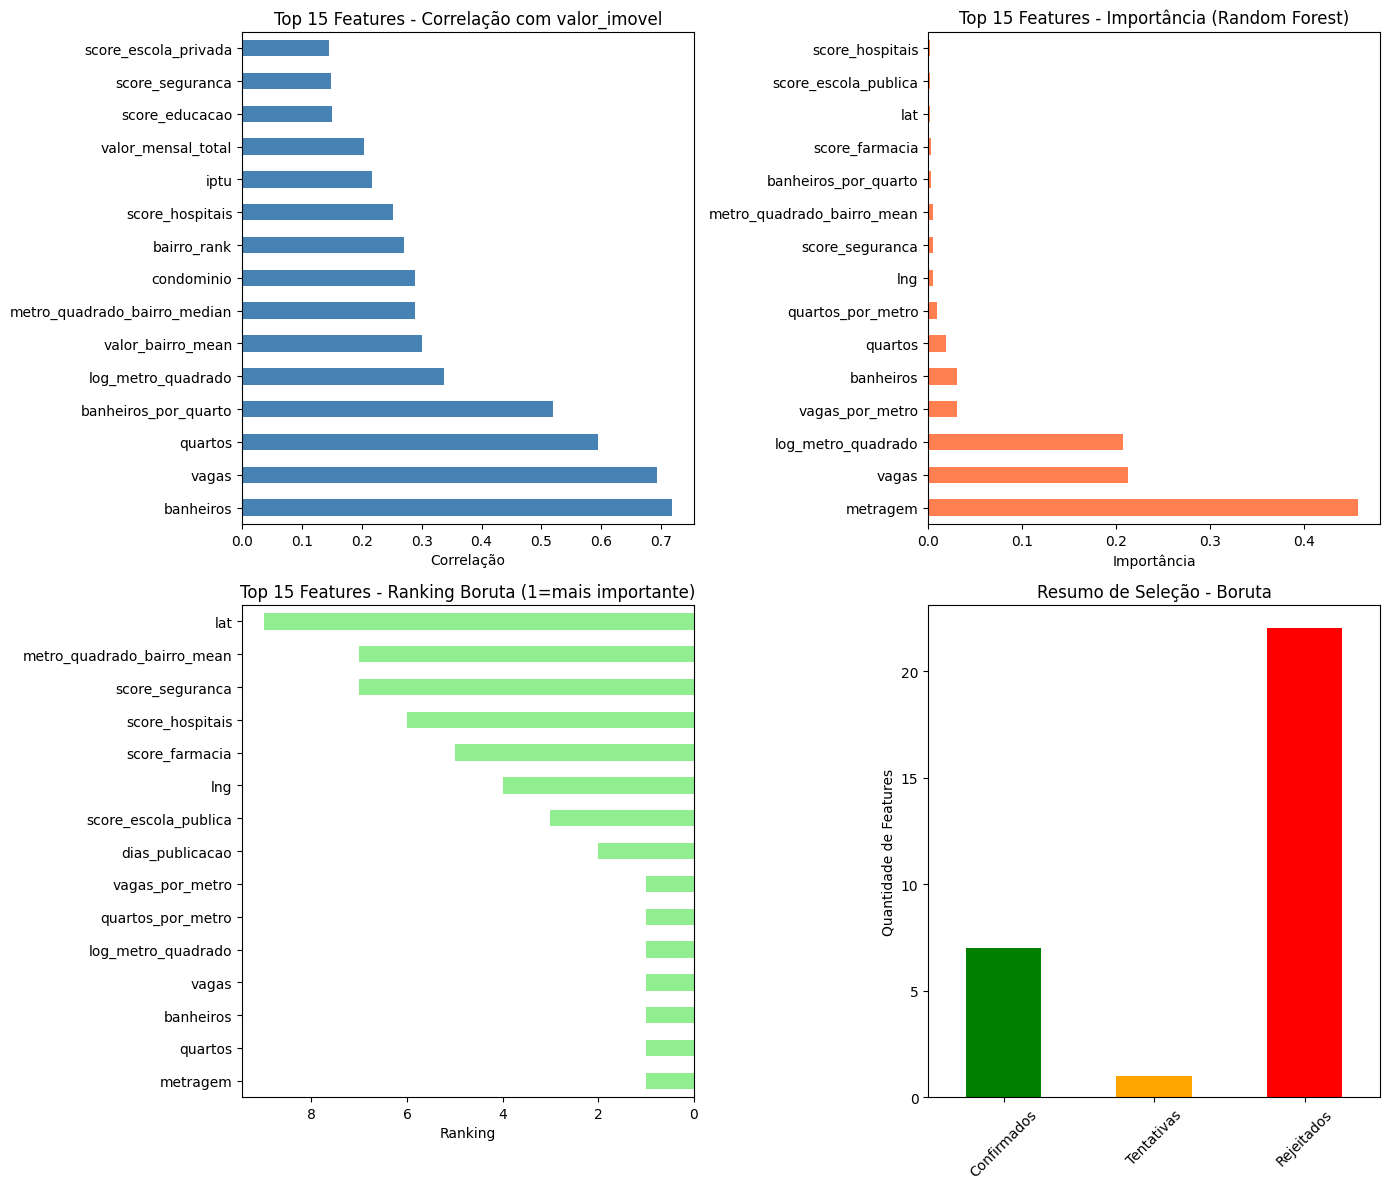


4. ANÁLISE DETALHADA DAS TOP FEATURES
--------------------------------------------------------------------------------

✓ metragem
  Correlação: 0.0450
  Importância RF: 0.4576
  Dados faltantes: 0 (0.0%)

✓ vagas
  Correlação: 0.6923
  Importância RF: 0.2120
  Dados faltantes: 0 (0.0%)

✓ log_metro_quadrado
  Correlação: 0.3372
  Importância RF: 0.2072
  Dados faltantes: 0 (0.0%)

✓ vagas_por_metro
  Correlação: -0.2118
  Importância RF: 0.0311
  Dados faltantes: 0 (0.0%)

✓ banheiros
  Correlação: 0.7188
  Importância RF: 0.0304
  Dados faltantes: 0 (0.0%)

5. SCATTER PLOTS DAS TOP FEATURES
--------------------------------------------------------------------------------


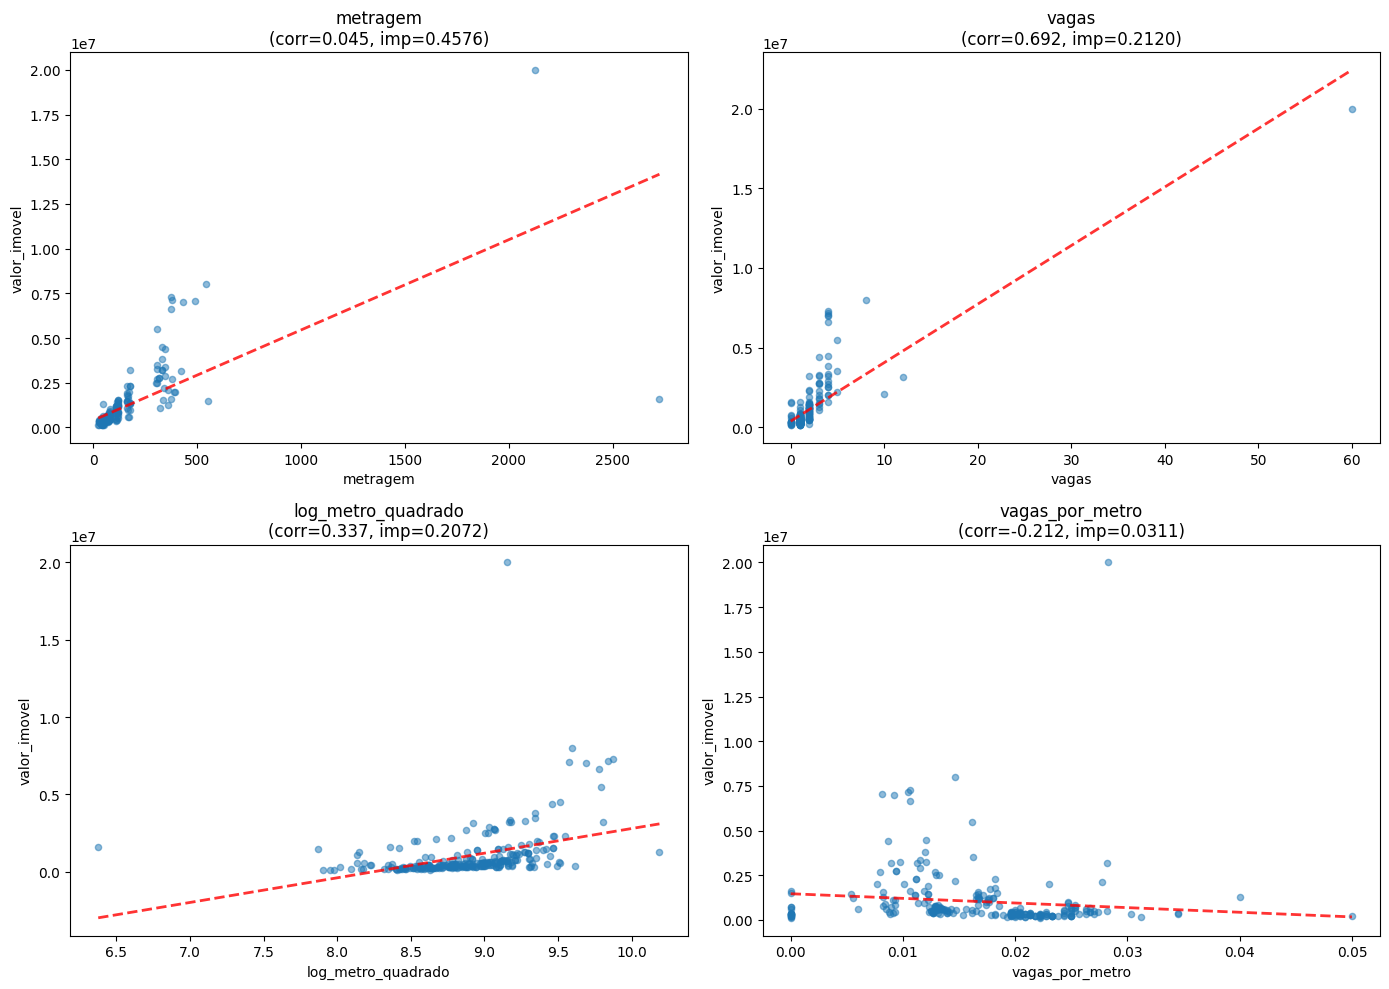


6. RECOMENDAÇÕES
--------------------------------------------------------------------------------

🎯 As 3 features mais promissoras para prever valor_imovel são:
1. metragem
   - Correlação: 0.0450
   - Importância: 0.4576
2. vagas
   - Correlação: 0.6923
   - Importância: 0.2120
3. log_metro_quadrado
   - Correlação: 0.3372
   - Importância: 0.2072

💡 Próximos passos recomendados:
- Metragem é naturalmente correlacionada; investigar se há multicolinearidade

✅ Análise de importância concluída!


In [104]:
# ============================================================================
# ANÁLISE DE IMPORTÂNCIA DAS NOVAS VARIÁVEIS
# ============================================================================

print('='*80)
print('ANÁLISE DE IMPORTÂNCIA DAS NOVAS VARIÁVEIS')
print('='*80)

# Preparar dataset para análise
analise_df = dados_melhorado.copy()



# Selecionar apenas apartamentos com dados completos
apartamentos_analise = analise_df[analise_df['tipo_imovel'] == 'apartamento'].copy()
apartamentos_analise = apartamentos_analise.dropna(subset=['preco_por_m2', 'valor_imovel'])

# 1. Análise de correlação
print('\n1. CORRELAÇÃO COM O ALVO (preco_por_m2)')
print('-' * 80)

feature_cols = ['metragem', 'quartos', 'banheiros', 'vagas', 'condominio', 
                'iptu', 'log_metro_quadrado',
                'metro_quadrado_bairro_mean', 'metro_quadrado_bairro_median',
                'valor_bairro_mean', 'bairro_rank', 'quartos_por_metro',
                'vagas_por_metro', 'banheiros_por_quarto', 'condominio_por_metro',
                'valor_mensal_total', 'tem_condominio',
                'score_escola_privada',
                'score_escola_publica', 'score_hospitais', 'score_mercado',
                'score_farmacia', 'score_parque', 'score_seguranca', 'score_educacao',
                'tem_elevador', 'novo_lancamento',
                'dias_publicacao',
                
                'lat', 'lng']

correlacoes = apartamentos_analise[feature_cols + ['valor_imovel']].corr()['valor_imovel'].drop('valor_imovel').sort_values(ascending=False)

print('\nTop 10 features mais correlacionadas com valor_imovel:')
print(correlacoes.head(10))

print('\nFeatures com correlação fraca/negativa:')
print(correlacoes.tail(5))

# 2. Importância via Random Forest
print('\n2. IMPORTÂNCIA VIA RANDOM FOREST')
print('-' * 80)

from sklearn.ensemble import RandomForestRegressor

# Preparar dados
X_analise = apartamentos_analise[feature_cols].copy()
y_analise = apartamentos_analise['valor_imovel'].copy()

# Preencher NaNs e remover valores infinitos / inválidos
X_analise = X_analise.replace([np.inf, -np.inf], np.nan)
X_analise = X_analise.fillna(X_analise.mean())
y_analise = y_analise.replace([np.inf, -np.inf], np.nan)

finite_y = np.isfinite(y_analise) & (np.abs(y_analise) < 1e16)
finite_X = X_analise.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
valid_mask = finite_y & finite_X
invalid_count = (~valid_mask).sum()
if invalid_count > 0:
    print(f'Filtrando {invalid_count} linhas com valores não finitos ou inválidos antes do treino.')
    X_analise = X_analise.loc[valid_mask]
    y_analise = y_analise.loc[valid_mask]

# Treinar RF simples para obter importância
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf.fit(X_analise, y_analise)

feature_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('\nTop 10 features por importância (Random Forest):')
print(feature_importance.head(10))

print('\nFeatures com importância muito baixa:')
print(feature_importance.tail(5))

# 2.5. Importância via Boruta
print('\n2.5. IMPORTÂNCIA VIA BORUTA (Feature Selection)')
print('-' * 80)

try:
    from boruta import BorutaPy
    
    # Usar Random Forest como estimador base
    rf_boruta = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # Executar Boruta
    print('Executando Boruta... (pode levar alguns segundos)')
    boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42, verbose=0)
    boruta.fit(X_analise.values, y_analise.values)
    
    # Resultados
    features_selecionados = X_analise.columns[boruta.support_].tolist()
    features_tentativas = X_analise.columns[boruta.support_weak_].tolist()
    features_rejeitados = X_analise.columns[~(boruta.support_ | boruta.support_weak_)].tolist()
    
    print(f'\n✓ Features CONFIRMADOS IMPORTANTES ({len(features_selecionados)}):')
    for feat in features_selecionados:
        print(f'  - {feat}')
    
    if features_tentativas:
        print(f'\n⚠ Features TENTATIVAS/BORDERLINE ({len(features_tentativas)}):')
        for feat in features_tentativas:
            print(f'  - {feat}')
    
    if features_rejeitados:
        print(f'\n✗ Features REJEITADOS ({len(features_rejeitados)}):')
        for feat in features_rejeitados:
            print(f'  - {feat}')
    
    # Ranking de importância do Boruta
    boruta_ranking = pd.Series(boruta.ranking_, index=X_analise.columns).sort_values()
    print('\n\nRanking do Boruta (1=mais importante):')
    print(boruta_ranking.head(15))
    
    print('\n✅ Boruta executado com sucesso!')
    
except ImportError:
    print('⚠ Boruta não instalado. Instalando...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'boruta'])
    from boruta import BorutaPy
    
    # Executar novamente após instalação
    rf_boruta = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42, verbose=0)
    boruta.fit(X_analise.values, y_analise.values)
    
    features_selecionados = X_analise.columns[boruta.support_].tolist()
    features_tentativas = X_analise.columns[boruta.support_weak_].tolist()
    features_rejeitados = X_analise.columns[~(boruta.support_ | boruta.support_weak_)].tolist()
    
    print(f'\n✓ Features CONFIRMADOS IMPORTANTES ({len(features_selecionados)}):')
    for feat in features_selecionados:
        print(f'  - {feat}')
    
    if features_tentativas:
        print(f'\n⚠ Features TENTATIVAS/BORDERLINE ({len(features_tentativas)}):')
        for feat in features_tentativas:
            print(f'  - {feat}')
    
    if features_rejeitados:
        print(f'\n✗ Features REJEITADOS ({len(features_rejeitados)}):')
        for feat in features_rejeitados:
            print(f'  - {feat}')
    
    boruta_ranking = pd.Series(boruta.ranking_, index=X_analise.columns).sort_values()
    print('\n\nRanking do Boruta (1=mais importante):')
    print(boruta_ranking.head(15))

# 3. Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Correlação
ax1 = axes[0, 0]
correlacoes.head(15).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 15 Features - Correlação com valor_imovel')
ax1.set_xlabel('Correlação')

# Importância RF
ax2 = axes[0, 1]
feature_importance.head(15).plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top 15 Features - Importância (Random Forest)')
ax2.set_xlabel('Importância')

# Ranking Boruta
try:
    ax3 = axes[1, 0]
    boruta_ranking.head(15).plot(kind='barh', ax=ax3, color='lightgreen')
    ax3.set_title('Top 15 Features - Ranking Boruta (1=mais importante)')
    ax3.set_xlabel('Ranking')
    ax3.invert_xaxis()  # Inverter para que 1 fique à direita (mais importante)
    
    # Resumo de seleção Boruta
    ax4 = axes[1, 1]
    boruta_summary = pd.Series({
        'Confirmados': len(features_selecionados),
        'Tentativas': len(features_tentativas),
        'Rejeitados': len(features_rejeitados)
    })
    colors_boruta = ['green', 'orange', 'red']
    boruta_summary.plot(kind='bar', ax=ax4, color=colors_boruta)
    ax4.set_title('Resumo de Seleção - Boruta')
    ax4.set_ylabel('Quantidade de Features')
    ax4.set_xlabel('')
    ax4.tick_params(axis='x', rotation=45)
except:
    # Se Boruta não executou, deixar espaço vazio
    ax3 = axes[1, 0]
    ax3.text(0.5, 0.5, 'Boruta não executado', ha='center', va='center')
    ax3.set_title('Ranking Boruta')
    ax3.axis('off')
    
    ax4 = axes[1, 1]
    ax4.text(0.5, 0.5, 'Resumo Boruta', ha='center', va='center')
    ax4.set_title('Resumo de Seleção')
    ax4.axis('off')

plt.tight_layout()
plt.show()

# 4. Análise individual das top features
print('\n4. ANÁLISE DETALHADA DAS TOP FEATURES')
print('-' * 80)

top_features = feature_importance.head(5).index.tolist()

for feat in top_features:
    corr = correlacoes[feat]
    imp = feature_importance[feat]
    print(f'\n✓ {feat}')
    print(f'  Correlação: {corr:.4f}')
    print(f'  Importância RF: {imp:.4f}')
    print(f'  Dados faltantes: {apartamentos_analise[feat].isna().sum()} ({apartamentos_analise[feat].isna().mean()*100:.1f}%)')

# 5. Scatter plots das top features
print('\n5. SCATTER PLOTS DAS TOP FEATURES')
print('-' * 80)

n_top = 4
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features[:n_top]):
    ax = axes[idx]
    sample = apartamentos_analise.sample(frac=0.3, random_state=42)
    ax.scatter(sample[feat], sample['valor_imovel'], alpha=0.5, s=20)
    
    try:
        if not sample[feat].isna().all():
            z = np.polyfit(sample[feat].dropna(), sample['valor_imovel'][sample[feat].notna()], 1)
            p = np.poly1d(z)
            x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        ax.set_xlabel(feat)
        ax.set_ylabel('valor_imovel')
        ax.set_title(f'{feat}\n(corr={correlacoes[feat]:.3f}, imp={feature_importance[feat]:.4f})')
    except Exception as e:
        ax.set_xlabel(feat)
        ax.set_ylabel('valor_imovel')
        ax.set_title(f'{feat}\n(corr={correlacoes[feat]:.3f}, imp={feature_importance[feat]:.4f})\n(Erro ao plotar linha de tendência)')    

plt.tight_layout()
plt.show()

# 6. Recomendações
print('\n6. RECOMENDAÇÕES')
print('-' * 80)

top_3 = feature_importance.head(3).index.tolist()

print(f'\n🎯 As 3 features mais promissoras para prever valor_imovel são:')
for i, feat in enumerate(top_3, 1):
    corr = correlacoes[feat]
    imp = feature_importance[feat]
    print(f'{i}. {feat}')
    print(f'   - Correlação: {corr:.4f}')
    print(f'   - Importância: {imp:.4f}')

print('\n💡 Próximos passos recomendados:')
if 'predicao_metro_quadrado' in top_3:
    print('- Manter predicao_metro_quadrado como feature primária')
if 'metragem' in top_3:
    print('- Metragem é naturalmente correlacionada; investigar se há multicolinearidade')
if 'metro_quadrado_bairro_median' in top_3 or 'bairro_rank' in top_3:
    print('- Features de localização têm alto poder preditivo; considerar target encoding')
if 'quartos_por_metro' in top_3 or 'vagas_por_metro' in top_3:
    print('- Razões por metro quadrado são promissoras; otimizar engenharia dessas features')

print('\n✅ Análise de importância concluída!')


In [94]:
features_tentativas, features_rejeitados, features_selecionados

(['bairro_rank'],
 ['condominio',
  'iptu',
  'metro_quadrado_bairro_mean',
  'banheiros_por_quarto',
  'condominio_por_metro',
  'valor_mensal_total',
  'tem_condominio',
  'score_escola_privada',
  'score_escola_publica',
  'score_hospitais',
  'score_mercado',
  'score_farmacia',
  'score_parque',
  'score_seguranca',
  'score_educacao',
  'tem_elevador',
  'novo_lancamento',
  'lat',
  'lng'],
 ['metragem',
  'quartos',
  'banheiros',
  'vagas',
  'log_metro_quadrado',
  'metro_quadrado_bairro_median',
  'valor_bairro_mean',
  'quartos_por_metro',
  'vagas_por_metro'])

ANÁLISE SHAP - EXPLICABILIDADE DO MODELO
✓ SHAP importado com sucesso

1. PREPARANDO DADOS PARA SHAP
--------------------------------------------------------------------------------
Usando amostra de 876 amostras para SHAP (total: 876)

2. UTILIZANDO MODELO RANDOM FOREST TREINADO
--------------------------------------------------------------------------------
Modelo RF disponível: RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)
Modelo score no dataset: 0.9832

3. CALCULANDO SHAP VALUES
--------------------------------------------------------------------------------
Criando explainer (TreeExplainer para Random Forest)...
Calculando SHAP values (pode levar alguns segundos)...
✓ SHAP values calculados: shape (876, 30)

4. VISUALIZAÇÕES SHAP - SUMMARY PLOTS
--------------------------------------------------------------------------------

5. VISUALIZAÇÕES SHAP - DEPENDENCE PLOTS
--------------------------------------------------------------------------------


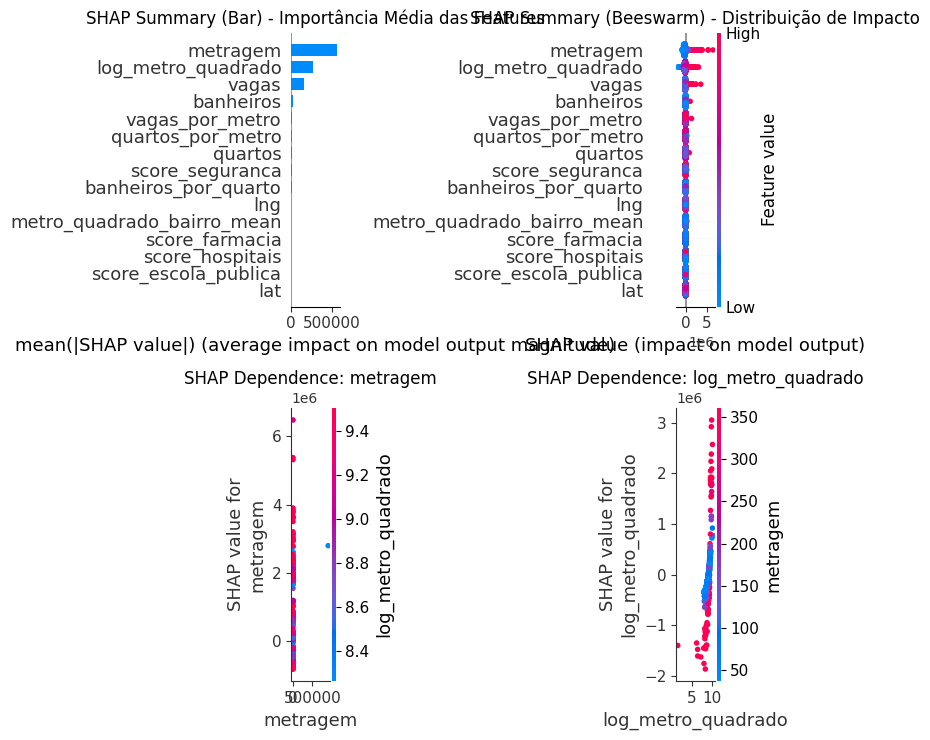


6. EXPLICAÇÃO INDIVIDUAL - FORCE PLOT
--------------------------------------------------------------------------------

Explainações de 3 predições individuais:

--- Amostra 1 ---
Valor real: 669417.00
Predição: 660834.11
Residuo: 8582.89
  Top 3 features mais influentes:
    1. metragem: 77.00 (↓ reduz, SHAP=-194011.8176)
    2. vagas: 1.00 (↓ reduz, SHAP=-85507.7744)
    3. log_metro_quadrado: 9.07 (↓ reduz, SHAP=-20289.5210)

--- Amostra 2 ---
Valor real: 138000.00
Predição: 144058.94
Residuo: -6058.94
  Top 3 features mais influentes:
    1. metragem: 42.00 (↓ reduz, SHAP=-413281.1680)
    2. log_metro_quadrado: 8.10 (↓ reduz, SHAP=-329285.7517)
    3. vagas: 1.00 (↓ reduz, SHAP=-83226.0636)

--- Amostra 3 ---
Valor real: 449000.00
Predição: 445499.18
Residuo: 3500.82
  Top 3 features mais influentes:
    1. metragem: 49.00 (↓ reduz, SHAP=-464085.7754)
    2. vagas: 1.00 (↓ reduz, SHAP=-86520.6717)
    3. log_metro_quadrado: 9.12 (↑ aumenta, SHAP=40927.6918)

7. ANÁLISE DE INTERAÇ

<Figure size 1200x600 with 0 Axes>

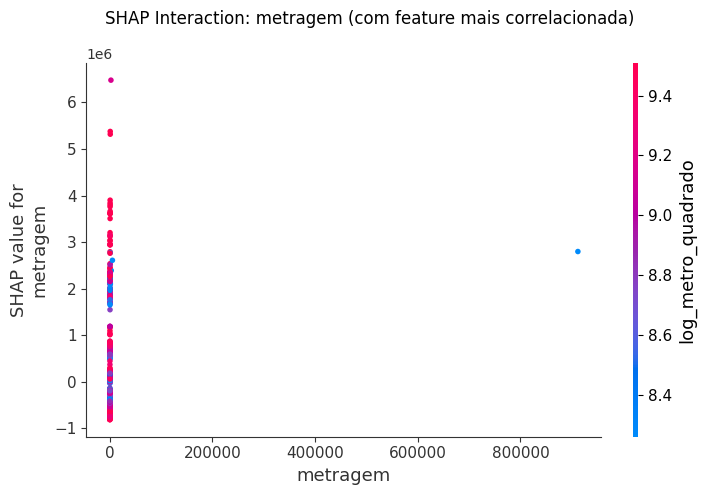


8. RESUMO - INTERPRETAÇÕES SHAP
--------------------------------------------------------------------------------

Top 10 Features por SHAP (impacto médio absoluto):
metragem                571336.221271
log_metro_quadrado      270140.270178
vagas                   160064.108626
banheiros                16960.464829
vagas_por_metro          13089.454502
quartos_por_metro        10988.698998
quartos                   5181.463680
score_seguranca           3860.914725
banheiros_por_quarto      3820.827998
lng                       2912.972213
dtype: float64

💡 Interpretações:
- SHAP values mostram o impacto marginal de cada feature na predição
- Valores positivos aumentam a predição; negativos reduzem
- A ordem pode diferir de Feature Importance (que mede uso) e Correlação
- Use para explicar predições individuais de forma confiável

✅ Análise SHAP concluída!


In [105]:
# ============================================================================
# ANÁLISE SHAP (SHapley Additive exPlanations) - EXPLICABILIDADE DO MODELO
# ============================================================================

print('='*80)
print('ANÁLISE SHAP - EXPLICABILIDADE DO MODELO')
print('='*80)

# Instalar shap se necessário
try:
    import shap
    print('✓ SHAP importado com sucesso')
except ImportError:
    print('⚠ SHAP não instalado. Instalando...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
    print('✓ SHAP instalado e importado')

# 1. Preparar dados para SHAP (usar amostra para não ser muito lento)
print('\n1. PREPARANDO DADOS PARA SHAP')
print('-' * 80)

# Usar amostra de dados para calcular SHAP (mais rápido)
sample_size = min(5000, len(X_analise))
sample_idx = np.random.choice(len(X_analise), size=sample_size, replace=False)
X_shap = X_analise.iloc[sample_idx].reset_index(drop=True)
y_shap = y_analise.iloc[sample_idx].reset_index(drop=True)

print(f'Usando amostra de {sample_size} amostras para SHAP (total: {len(X_analise)})')

# 2. Criar ou usar modelo treinado (Random Forest)
print('\n2. UTILIZANDO MODELO RANDOM FOREST TREINADO')
print('-' * 80)

# O modelo rf já foi treinado na célula anterior
print(f'Modelo RF disponível: {rf}')
print(f'Modelo score no dataset: {rf.score(X_shap, y_shap):.4f}')

# 3. Calcular SHAP values usando TreeExplainer (eficiente para RF)
print('\n3. CALCULANDO SHAP VALUES')
print('-' * 80)

try:
    print('Criando explainer (TreeExplainer para Random Forest)...')
    explainer = shap.TreeExplainer(rf)
    
    print('Calculando SHAP values (pode levar alguns segundos)...')
    shap_values = explainer.shap_values(X_shap)
    
    # Para regressão, shap_values é uma array (não lista)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]  # Usar última classe/output se for list
    
    print(f'✓ SHAP values calculados: shape {shap_values.shape}')
    
except Exception as e:
    print(f'⚠ Erro ao calcular SHAP values: {e}')
    print('Tentando com amostra menor...')
    sample_size = min(1000, len(X_analise))
    sample_idx = np.random.choice(len(X_analise), size=sample_size, replace=False)
    X_shap = X_analise.iloc[sample_idx].reset_index(drop=True)
    y_shap = y_analise.iloc[sample_idx].reset_index(drop=True)
    
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    print(f'✓ SHAP values recalculados com {sample_size} amostras')

# 4. Summary Plot - Importância global via SHAP
print('\n4. VISUALIZAÇÕES SHAP - SUMMARY PLOTS')
print('-' * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Summary plot (bar) - importância média dos SHAP values
ax1 = axes[0, 0]
plt.sca(ax1)
try:
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=15)
    ax1.set_title('SHAP Summary (Bar) - Importância Média das Features')
except Exception as e:
    print(f'⚠ Erro no summary_plot (bar): {e}')
    ax1.text(0.5, 0.5, 'Erro ao renderizar', ha='center', va='center')

# Summary plot (beeswarm) - distribuição dos SHAP values
ax2 = axes[0, 1]
plt.sca(ax2)
try:
    shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    ax2.set_title('SHAP Summary (Beeswarm) - Distribuição de Impacto')
except Exception as e:
    print(f'⚠ Erro no summary_plot (beeswarm): {e}')
    ax2.text(0.5, 0.5, 'Erro ao renderizar', ha='center', va='center')

# 5. Dependence Plots - Top 2 features
print('\n5. VISUALIZAÇÕES SHAP - DEPENDENCE PLOTS')
print('-' * 80)

# Obter top 2 features por SHAP
shap_importance = np.abs(shap_values).mean(axis=0)
top_2_features_idx = np.argsort(shap_importance)[-2:][::-1]
top_2_features = [X_shap.columns[i] for i in top_2_features_idx]

for idx, feat_idx in enumerate(top_2_features_idx):
    ax = axes[1, idx]
    plt.sca(ax)
    feat_name = X_shap.columns[feat_idx]
    try:
        shap.dependence_plot(feat_idx, shap_values, X_shap, show=False, ax=ax)
        ax.set_title(f'SHAP Dependence: {feat_name}')
    except Exception as e:
        print(f'⚠ Erro no dependence_plot para {feat_name}: {e}')
        ax.text(0.5, 0.5, f'Erro: {feat_name}', ha='center', va='center')

plt.tight_layout()
plt.show()

# 6. Força Plot (Force Plot) - Explicação individual
print('\n6. EXPLICAÇÃO INDIVIDUAL - FORCE PLOT')
print('-' * 80)

# Mostrar força plot para algumas instâncias
n_examples = 3
print(f'\nExplainações de {n_examples} predições individuais:')

try:
    expected_value = explainer.expected_value
    for i in range(min(n_examples, len(X_shap))):
        print(f'\n--- Amostra {i+1} ---')
        print(f'Valor real: {y_shap.iloc[i]:.2f}')
        print(f'Predição: {rf.predict(X_shap.iloc[[i]])[0]:.2f}')
        print(f'Residuo: {y_shap.iloc[i] - rf.predict(X_shap.iloc[[i]])[0]:.2f}')
        
        # Mostrar top 3 features mais importantes para essa predição
        instance_shap = shap_values[i]
        top_features_idx = np.argsort(np.abs(instance_shap))[-3:][::-1]
        print('  Top 3 features mais influentes:')
        for j, feat_idx in enumerate(top_features_idx, 1):
            feat_name = X_shap.columns[feat_idx]
            shap_val = instance_shap[feat_idx]
            feat_val = X_shap.iloc[i, feat_idx]
            direction = '↑ aumenta' if shap_val > 0 else '↓ reduz'
            print(f'    {j}. {feat_name}: {feat_val:.2f} ({direction}, SHAP={shap_val:.4f})')
except Exception as e:
    print(f'⚠ Erro ao gerar explanations individuais: {e}')

# 7. Feature Interaction Plot
print('\n7. ANÁLISE DE INTERAÇÕES ENTRE FEATURES')
print('-' * 80)

try:
    # Calcular interações com a feature mais importante
    most_important_idx = np.argsort(shap_importance)[-1]
    most_important_feat = X_shap.columns[most_important_idx]
    
    print(f'Feature mais importante: {most_important_feat}')
    print('Criando interaction plot (pode levar alguns segundos)...')
    
    fig_inter = plt.figure(figsize=(12, 6))
    shap.dependence_plot(most_important_idx, shap_values, X_shap, 
                         interaction_index="auto", show=False)
    plt.suptitle(f'SHAP Interaction: {most_important_feat} (com feature mais correlacionada)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'⚠ Erro ao criar interaction plot: {e}')

# 8. Resumo SHAP
print('\n8. RESUMO - INTERPRETAÇÕES SHAP')
print('-' * 80)

# Estatísticas dos SHAP values
shap_abs_mean = np.abs(shap_values).mean(axis=0)
shap_ranking = pd.Series(shap_abs_mean, index=X_shap.columns).sort_values(ascending=False)

print('\nTop 10 Features por SHAP (impacto médio absoluto):')
print(shap_ranking.head(10))

print('\n💡 Interpretações:')
print('- SHAP values mostram o impacto marginal de cada feature na predição')
print('- Valores positivos aumentam a predição; negativos reduzem')
print('- A ordem pode diferir de Feature Importance (que mede uso) e Correlação')
print('- Use para explicar predições individuais de forma confiável')

print('\n✅ Análise SHAP concluída!')


# Testando varias features, varias transformacoes e vario modelos

## Importando os dados

In [1]:
from pathlib import Path
import pandas as pd
cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / "joinville"
pd_joinville = pd.read_parquet(PASTA_DADOS / f'joinville_com_ind_local_2026-05.parquet')

In [2]:
from criando_indices_individuais import CriandoIndicesIndividuais

cidade = "Joinville, Santa Catarina, Brasil"

indices = CriandoIndicesIndividuais(cidade=cidade)

pd_joinville = indices.calcular_indices(imoveis_df=pd_joinville)

Baixando dados de POIs do OpenStreetMap...
  -> hospital...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> mercado...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> farmacia...
  -> parque...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  -> escola...
  -> policia...


C:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\src\criando_indices_individuais.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


7 categorias de POIs carregadas.


In [3]:
TARGET = "valor_imovel"
df_modelo = pd_joinville.copy()
#df_modelo = df_modelo.dropna(subset=[TARGET, "metragem"])
df_modelo = df_modelo[
    (df_modelo["metragem"] > 10)
    #& (df_modelo[TARGET] >= 50_000)
    #& (df_modelo[TARGET] <= 25_000_000)
    & ((df_modelo["tipo_imovel"] == "casa") | (df_modelo["preco_por_m2"] >= 100))
    & ((df_modelo["tipo_imovel"] == "apartamento") | (df_modelo["preco_por_m2"] >= 100))
].copy()


## Dividindo os dados treino, teste e validacao

In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df_modelo, test_size=0.25, random_state=42
)

In [5]:


train, val_teste = train_test_split(
    df_modelo, test_size=0.25, random_state=42
)

val, test = train_test_split(
    val_teste, test_size=0.4, random_state=42
)

print(f"Amostras para treino: {len(train):,} | teste: {len(test):,} | validação: {len(val):,}")

Amostras para treino: 19,923 | teste: 2,657 | validação: 3,985


## Criando novas features

In [6]:
# 4. Engenharia de features de localização
print('\n4. ENGENHARIA DE FEATURES DE LOCALIZAÇÃO')
print('-' * 80)

# Estatísticas por bairro
bairro_stats = train.groupby('bairro').agg({
    'preco_por_m2': ['mean', 'median', 'count'],
    'valor_imovel': ['mean', 'median']
}).fillna(0)

## metro_quadrado_bairro_mean

train['metro_quadrado_bairro_mean'] = train['bairro'].map(
    bairro_stats[('preco_por_m2', 'mean')]
)

val['metro_quadrado_bairro_mean'] = val['bairro'].map(
    bairro_stats[('preco_por_m2', 'mean')]
)

test['metro_quadrado_bairro_mean'] = test['bairro'].map(
    bairro_stats[('preco_por_m2', 'mean')]
)

## metro_quadrado_bairro_median

train['metro_quadrado_bairro_median'] = train['bairro'].map(
    bairro_stats[('preco_por_m2', 'median')]
)
val['metro_quadrado_bairro_median'] = val['bairro'].map(
    bairro_stats[('preco_por_m2', 'median')]    
)
test['metro_quadrado_bairro_median'] = test['bairro'].map(
    bairro_stats[('preco_por_m2', 'median')]
)

## valor_bairro_mean
train['valor_bairro_mean'] = train['bairro'].map(
    bairro_stats[('valor_imovel', 'mean')]
)
val['valor_bairro_mean'] = val['bairro'].map(
    bairro_stats[('valor_imovel', 'mean')]
)
test['valor_bairro_mean'] = test['bairro'].map(
    bairro_stats[('valor_imovel', 'mean')]
)   

# Criar ranking de bairros por preço
bairro_rank = train.groupby('bairro')['preco_por_m2'].median().rank()

train['bairro_rank'] = train['bairro'].map(bairro_rank)
val['bairro_rank'] = val['bairro'].map(bairro_rank)
test['bairro_rank'] = test['bairro'].map(bairro_rank)

# Razões
train['quartos_por_metro'] = train['quartos'] / (train['metragem'] + 1)
val['quartos_por_metro'] = val['quartos'] / (val['metragem'] + 1)
test['quartos_por_metro'] = test['quartos'] / (test['metragem'] + 1)

train['vagas_por_metro'] = train['vagas'] / (train['metragem'] + 1)
val['vagas_por_metro'] = val['vagas'] / (val['metragem'] + 1)
test['vagas_por_metro'] = test['vagas'] / (test['metragem'] + 1)

train['banheiros_por_quarto'] = train['banheiros'] / (train['quartos'] + 1)
val['banheiros_por_quarto'] = val['banheiros'] / (val['quartos'] + 1)
test['banheiros_por_quarto'] = test['banheiros'] / (test['quartos'] + 1)

train['condominio_por_metro'] = train['condominio'] / (train['metragem'] + 1)
val['condominio_por_metro'] = val['condominio'] / (val['metragem'] + 1)
test['condominio_por_metro'] = test['condominio'] / (test['metragem'] + 1)



4. ENGENHARIA DE FEATURES DE LOCALIZAÇÃO
--------------------------------------------------------------------------------


In [7]:
train.shape, test.shape, val.shape

((19923, 63), (2657, 63), (3985, 63))

In [8]:
train.columns

Index(['url', 'titulo', 'metragem', 'banheiros', 'vagas', 'quartos',
       'valor_imovel', 'condominio', 'endereco', 'iptu', 'descricao',
       'data_criacao', 'caracteristicas', 'fotos', 'link_maps', 'fonte', 'rua',
       'numero', 'bairro', 'cidade', 'estado', 'cep', 'dias_publicacao',
       'tipo_imovel', 'lat', 'lng', 'preco_por_m2', 'faixa', 'p25_bairro',
       'p50_bairro', 'p75_bairro', 'desvio_mediana', 'score',
       'dist_escolas_privadas_mais_proximo', 'qtd_escolas_privadas_500m',
       'dist_escolas_publicas_mais_proximo', 'qtd_escolas_publicas_500m',
       'dist_hospital_mais_proximo', 'qtd_hospital_1000m',
       'dist_mercado_mais_proximo', 'qtd_mercado_500m',
       'dist_farmacia_mais_proximo', 'qtd_farmacia_300m',
       'dist_parque_mais_proximo', 'qtd_parque_1000m',
       'dist_policia_mais_proximo', 'qtd_policia_500m', 'score_escola_privada',
       'score_escola_publica', 'score_hospitais', 'score_mercado',
       'score_farmacia', 'score_parque', 'score_

## Dividindo x and y

In [9]:
CATEGORICAL_FEATURES = ['tipo_imovel', 'bairro']
NUMERIC_FEATURES = ['metragem', 'quartos', 'banheiros', 'vagas', 'score_escola_privada', 
                    'score_escola_publica', 'score_hospitais', 'score_mercado',
                    'score_farmacia', 'score_parque', 'score_seguranca', 'score_educacao',
                    'metro_quadrado_bairro_mean', 'metro_quadrado_bairro_median',
                    'valor_bairro_mean', 'bairro_rank',
                    'quartos_por_metro', 'vagas_por_metro', 'banheiros_por_quarto',
                    'lat', 'lng']

TARGET = 'valor_imovel'

In [10]:
X_train = train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train[TARGET]

X_val = val[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = val[TARGET]

X_test = test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test[TARGET]

print(f"Amostras para treino: {X_train.shape} | teste: {X_test.shape} | validação: {X_val.shape}")

Amostras para treino: (19923, 23) | teste: (2657, 23) | validação: (3985, 23)


## Conectando mlflow

In [11]:
from  mlflow_manager import MLflowManager

# Ou explicito:
mlf = MLflowManager(
    nome_experimento="imoveis-joinville-valor",
    databricks_workspace_path="/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville-valor",
)

mlf.conectar()

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville-valor


'databricks'

## Criando funcoes

In [35]:
from mlflow_manager import MLflowManager
from mlflow.tracking import MlflowClient

mgr = MLflowManager()
mgr.conectar()

client = MlflowClient(mgr.get_tracking_uri())
exp = client.get_experiment_by_name("/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville-valor")

runs = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=["metrics.r2 DESC"],
    max_results=2000,
)

rows = []
for r in runs:
    p = r.data.params
    t = r.data.tags
    m = r.data.metrics
    rows.append({
        "run_name": r.info.run_name,
        "modelo": t.get("modelo") or p.get("modelo"),
        "tratamento": t.get("tratamento") or p.get("tratamento"),
        "n_features": t.get("n_features") or p.get("n_features"),
        "transform": p.get("transform", "none"),
        "scaler": t.get("scaler"),
        "imputer_num": t.get("imputer_num"),
        "encoder": t.get("encoder"), 
        "r2": m.get("r2"),
        "rmse": m.get("rmse"),
        "mape": m.get("mape"),
        "mdape": m.get("mdape"),
        "feature_transform"  : t.get("feature_transform_map")
    })

df = pd.DataFrame(rows).dropna(subset=["r2"])

# Melhor geral por R²
df.sort_values("r2", ascending=False).head(10)

# Melhor por modelo
df.loc[df.groupby("modelo")["r2"].idxmax()].sort_values("r2", ascending=False)

# Melhor por tratamento + transform
df.loc[df.groupby(["tratamento", "transform"])["r2"].idxmax()].sort_values("r2", ascending=False)

# Top modelos com >= 5 features
df[df["n_features"].astype(int) >= 5].sort_values("r2", ascending=False).head(20)

[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Users/sehnemjeferson@gmail.com/preco-imoveis-joinville


,run_name,modelo,tratamento,n_features,transform,scaler,imputer_num,encoder,r2,rmse,mape,mdape,feature_transform
0,RandomForest|robust_median_ohe|log_tem_elevado...,RandomForest,robust_median_ohe,25,log,RobustScaler,median,OneHotEncoder,0.676531,974655.155819,24.426627,12.897435,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
1,RandomForest|std_median_ohe|log_tem_elevador_2...,RandomForest,std_median_ohe,25,log,StandardScaler,median,OneHotEncoder,0.676416,974828.769985,24.426613,12.897435,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
2,RandomForest|minmax_mean_ohe|log_tem_elevador_...,RandomForest,minmax_mean_ohe,25,log,MinMaxScaler,mean,OneHotEncoder,0.676165,975206.473177,24.414596,12.887760,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
4,RandomForest|std_median_ohe|log_bairro_2026_06,RandomForest,std_median_ohe,23,log,StandardScaler,median,OneHotEncoder,0.675059,976870.541346,24.442160,12.883245,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
5,RandomForest|robust_median_ohe|log_bairro_2026_06,RandomForest,robust_median_ohe,23,log,RobustScaler,median,OneHotEncoder,0.675046,976889.274384,24.442334,12.883245,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
6,RandomForest|std_median_ohe|sqrt_tem_elevador_...,RandomForest,std_median_ohe,25,sqrt,StandardScaler,median,OneHotEncoder,0.674979,976990.188168,24.260540,12.887056,"{""metragem"": ""sqrt"", ""quartos"": ""sqrt"", ""banhe..."
7,RandomForest|robust_median_ohe|sqrt_tem_elevad...,RandomForest,robust_median_ohe,25,sqrt,RobustScaler,median,OneHotEncoder,0.674867,977158.942743,24.260761,12.887056,"{""metragem"": ""sqrt"", ""quartos"": ""sqrt"", ""banhe..."
8,RandomForest|robust_median_ohe|log_tipo_imovel...,RandomForest,robust_median_ohe,22,log,RobustScaler,median,OneHotEncoder,0.674743,977345.649057,24.470720,12.961824,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
9,RandomForest|std_median_ohe|log_tipo_imovel_20...,RandomForest,std_median_ohe,22,log,StandardScaler,median,OneHotEncoder,0.674714,977388.820583,24.470248,12.961824,"{""metragem"": ""log"", ""quartos"": ""log"", ""banheir..."
10,RandomForest|minmax_mean_ohe|sqrt_tem_elevador...,RandomForest,minmax_mean_ohe,25,sqrt,MinMaxScaler,mean,OneHotEncoder,0.674504,977703.712903,24.264616,12.877397,"{""metragem"": ""sqrt"", ""quartos"": ""sqrt"", ""banhe..."


In [45]:
def buscar_todos_runs(client, experiment_id):
    """Busca TODOS os runs com paginação."""
    all_runs = []
    page_token = None

    while True:
        results = client.search_runs(
            experiment_ids=[experiment_id],
            max_results=5000,       # ← maior que o default
            page_token=page_token,  # ← paginação
        )
        all_runs.extend(results)

        if not results.token:       # ← fim da páginação
            break
        page_token = results.token

    return all_runs

runs = buscar_todos_runs(client, exp.experiment_id)
print(f"Total de runs carregados: {len(runs)}")  # ~7500

Total de runs carregados: 1115


In [ ]:
runs

In [ ]:

import pandas as pd
import argparse
from pathlib import Path
from mlflow_manager import MLflowManager
from mlflow.tracking import MlflowClient


def buscar_runs_mlflow():
    mgr = MLflowManager()
    mgr.conectar()
    client = MlflowClient(mgr.get_tracking_uri())
    exp = client.get_experiment_by_name("/Users/sehnemjeferson@gmail.com/imoveis-joinville-valor")
    if not exp:
        print(f"Experimento '{mgr.nome_experimento}' nao encontrado")
        return None

    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        max_results=5000,
    )

    rows = []
    for r in runs:
        if not r.data.metrics:
            continue
        p = r.data.params
        t = r.data.tags
        m = r.data.metrics
        rows.append({
            "run_name": r.info.run_name or "",
            "modelo": t.get("modelo") or p.get("modelo", ""),
            "tratamento": t.get("tratamento") or p.get("tratamento", ""),
            "n_features": int(t.get("n_features") or p.get("n_features", 0) or 0),
            "transform": p.get("transform", "none"),
            "scaler": t.get("scaler", ""),
            "imputer_num": t.get("imputer_num", ""),
            "encoder": t.get("encoder", ""),
            "r2": m.get("r2"),
            "rmse": m.get("rmse"),
            "mape": m.get("mape"),
            "mdape": m.get("mdape"),
            "feature_transform": t.get("feature_transform_map", "{}"),
        })

    df = pd.DataFrame(rows)
    #df = df.dropna(subset=["r2"])
    return df


def analise_a_melhor_por_modelo(df, min_features=1):
    """Melhor R² de cada modelo."""
    df_filt = df[df["n_features"] >= min_features]
    idx = df_filt.groupby("modelo")["r2"].idxmax()
    cols = ["modelo", "r2", "rmse", "mape", "mdape", "n_features",
            "tratamento", "transform", "scaler", "feature_transform"]
    return df_filt.loc[idx, cols].sort_values("r2", ascending=False)


def analise_c_modelo_por_features(df, min_features=1):
    """Melhor R² de cada modelo em cada numero de features."""
    df_filt = df[df["n_features"] >= min_features]
    idx = df_filt.groupby(["modelo", "n_features"])["r2"].idxmax()
    cols = ["modelo", "n_features", "r2", "rmse", "mape", "tratamento", "transform"]
    return df_filt.loc[idx, cols].sort_values(["modelo", "n_features"])

def melhor_por_incremento(df, metric="r2", min_features=1):
    """Melhor combinacao (modelo + tratamento + transform) para cada n_features."""
    ascending = metric not in ("r2",)
    df_filt = df[df["n_features"] >= min_features].copy()
    idx = df_filt.groupby("n_features")[metric].idxmax() if not ascending else df_filt.groupby("n_features")[metric].idxmin()
    cols = ["n_features", "modelo", "tratamento", "transform",
            "r2", "rmse", "mape", "mdape"]
    return df_filt.loc[idx, cols].sort_values("n_features")

def top_20_geral(df, min_features=1):
    df_filt = df[df["n_features"] >= min_features]
    cols = ["run_name", "modelo", "tratamento", "n_features", "transform",
            "r2", "rmse", "mape", "mdape"]
    return df_filt.sort_values("r2", ascending=False).head(20)[cols]

MIN_FEATURES = 5
METRIC = "r2"

df = buscar_runs_mlflow()
if df is None or df.empty:
    print("Nenhum run encontrado")
   

print(f"\nTotal de runs: {len(df)}")
print(f"Modelos: {df['modelo'].unique()}")
print(f"Features: {df['n_features'].min()} a {df['n_features'].max()}")
print(f"Metrica: {METRIC}")

print("\n" + "=" * 70)
print("A — MELHOR DE CADA MODELO")
print("=" * 70)
print(analise_a_melhor_por_modelo(df,MIN_FEATURES).to_string(index=False))

print("\n" + "=" * 70)
print("C — MELHOR DE CADA MODELO × N_FEATURES")
print("=" * 70)
ac = analise_c_modelo_por_features(df, MIN_FEATURES)
for modelo in ac["modelo"].unique():
    sub = ac[ac["modelo"] == modelo].head(10)
    print(f"\n{modelo}:")
    print(sub.to_string(index=False))
    
print("\n" + "=" * 70)
print("C — MELHOR A CADA INCREMENTO DE FEATURE")
print("=" * 70)

print(melhor_por_incremento(df))

print("\n" + "=" * 70)
print("TOP 20 GERAL")
print("=" * 70)
print(top_20_geral(df, MIN_FEATURES).to_string(index=False))

[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Users/sehnemjeferson@gmail.com/preco-imoveis-joinville

Total de runs: 370
Modelos: ['GradientBoosting' 'KNeighbors' 'RandomForest' 'DecisionTree' 'Linear']
Features: 22 a 25
Metrica: r2

A — MELHOR DE CADA MODELO
          modelo       r2         rmse      mape     mdape  n_features        tratamento  transform           scaler                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           